# Milestone 1 · Audit of our 11 tables, before any cleaning

**What this part is.** The exploratory data analysis (EDA) we do *before* cleaning, for 11 of the 14 tables of the Formula 1 dataset: `seasons`, `circuits`, `drivers`, `constructors`, `status`, `sprint_results`, `driver_standings`, `constructor_standings`, `constructor_results`, `lap_times` and `pit_stops`. The other tables (`races`, `results`, `qualifying`) are audited by our teammates; we only read `races` and `results` to look things up.

**Why we do it.** The brief asks for EDA before and after cleaning, supported by code and plots, with every choice justified. It also warns that results, points and post-race standings are "future" information. What we find here decides how each table is cleaned, which of its data may be used before the race, and how the three data-engineering questions can be answered. (The "after cleaning" EDA repeats the key checks on the cleaned copies.)

**How to read it.** Every step has the same three parts:
1. **Why we look at this**: the question we ask.
2. **The code** that answers it, with a short comment on every block.
3. **What we saw** (the numbers) and **what we learnt** (what we will do about it). We only draw a conclusion after we have seen it in an output.

**Rules for the whole notebook.** The raw files are never changed (step 4.4 proves it); every step works on copies. The text `\N` is how the dataset writes a missing value. The prediction cutoff is *after qualifying, before the race*, so for every table we also ask: *could this be known before the race starts?* The figures are saved in the folder `figures/`. Every threshold is a choice we state together with the numbers behind it, and where a statement rests on general F1 knowledge instead of a printed output, we say so.

---

### Roadmap

| Part | Tables | The question we ask | Steps |
|---|---|---|---|
| **0 · Setup** | all | Can we load everything untouched, and what is one row in each table? Is the grain of `results` really one row per driver per race? | 0.1 to 0.2 |
| **1 · Reference tables** | `seasons`, `circuits`, `drivers`, `constructors`, `status` | Are the lists valid, how is each thing identified, and what must be prepared for Questions 1 to 3? | 1.1 to 1.6 |
| **2 · Race-level tables** | `sprint_results`, `driver_standings`, `constructor_standings`, `constructor_results` | When is each table written, and is it safe to use before the race? | 2.1 to 2.5 |
| **3 · Lap-level tables** | `lap_times`, `pit_stops` | Which races have the data, which values are extreme, and does it agree with `results`? | 3.1 to 3.4 |
| **4 · All tables together** | all | Do the tables fit together? How far back does each go? What is missing? Are the raw files intact? | 4.1 to 4.4 |
| **5 · What we learnt** | all | What did all of this change in our plan, and what is still open? | 5.1 to 5.2 |

---
## Part 0 · Setup

### 0.1 Load the 11 tables untouched, and map them

**Why we look at this.** To count `\N` and check formats, we first read every column as *text*, so that nothing is converted or hidden. These untouched tables are the raw layer (\"bronze\"), and we store a fingerprint (hash) of each so that step 4.4 can prove they never changed. We also define four small helpers that every step uses: `as_num` (a typed copy where `\N` becomes missing and number columns become numbers), `profile` (counts `\N` per column), `pk_check` (tests whether a column or a combination of columns is a valid key) and `save_fig`. Finally we write a map of the 11 tables. Its first three columns (what one row is, which key, which tables it points at) are what we *expect* from the column names and from the brief, and we typed them; everything else in the map is computed by code, including a test of every key. The links and the meaning of \"one row\" are tested in step 4.1 and in the table steps.

In [1]:
# ------------------------------------------------------------------------------------------
# 0.1  Setup: libraries, data folder, and loading every table exactly as delivered
# ------------------------------------------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 160)
print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)

# Kaggle mounts the dataset under /kaggle/input. We look for the folder that contains races.csv
# (on a laptop we fall back to the local folder "data").
def find_data_dir():
    for folder, _, files in os.walk("/kaggle/input"):
        if "races.csv" in files:
            return folder
    return "data"

DATA_DIR = find_data_dir()
print("Data folder:", DATA_DIR, "| CSV files found:", len([f for f in os.listdir(DATA_DIR) if f.endswith(".csv")]))

# The 11 tables we audit. races and results belong to our teammates; we only read them to look things up.
MINE = ["seasons", "circuits", "drivers", "constructors", "status", "sprint_results", "driver_standings",
        "lap_times", "pit_stops", "constructor_standings", "constructor_results"]

# The dataset does not leave missing cells empty: it writes the text \N. A value that stands in for
# "missing" like this is called a sentinel.
SENT = r"\N"

# RAW layer ("bronze"): every file exactly as delivered, every column read as TEXT so that nothing is
# converted or hidden (keep_default_na=False stops pandas from turning \N into NaN by itself).
raw = {t: pd.read_csv(f"{DATA_DIR}/{t}.csv", dtype=str, keep_default_na=False) for t in MINE + ["races", "results"]}

# A fingerprint (hash) of every raw table. In step 4.4 we compute it again to PROVE the raw data never changed.
RAW_HASH = {t: pd.util.hash_pandas_object(df).sum() for t, df in raw.items()}


# ---------- helper functions used by every step ----------
def as_num(df):
    """Exploring copy: \\N becomes NaN, and every column that holds only numbers becomes numeric.
    Columns with any real text (e.g. lap times like "1:26.572") stay text so we can still inspect their format."""
    out = df.replace(SENT, np.nan)
    for c in out.columns:
        converted = pd.to_numeric(out[c], errors="coerce")
        if converted.notna().sum() == out[c].notna().sum():       # did EVERY non-missing value convert?
            out[c] = converted
    return out

def profile(t):
    """One row per column of raw table t: how many \\N, how many different values, how many read as numbers."""
    df = raw[t]
    return pd.DataFrame({"missing (\\N)": df.eq(SENT).sum(),
                         "missing %": (df.eq(SENT).mean() * 100).round(2),
                         "different values": df.nunique(),
                         "reads as number %": df.apply(lambda s: pd.to_numeric(s, errors="coerce").notna().mean() * 100).round(1)})

def pk_check(t, cols):
    """Is the column (or the combination of columns) `cols` a valid primary key of table t?"""
    df = raw[t]
    return {"table": t, "key": "+".join(cols), "rows": len(df),
            "duplicates": int(df.duplicated(cols).sum()),                           # rows whose key appears again
            "missing": int(df[cols].isin(["", SENT]).any(axis=1).sum())}            # rows with a missing key part

def save_fig(name):
    """Tidy the figure, save it for the report, and show it."""
    plt.tight_layout()
    os.makedirs("figures", exist_ok=True)
    plt.savefig(f"figures/{name}.png", dpi=120, bbox_inches="tight")
    plt.show()


# ---------- exploring copies (the raw tables are never modified) ----------
seasons, circuits, drivers, constructors, status = (as_num(raw[t]) for t in ["seasons", "circuits", "drivers", "constructors", "status"])
sprint, driver_st, constructor_st, constructor_res = (as_num(raw[t]) for t in ["sprint_results", "driver_standings",
                                                                               "constructor_standings", "constructor_results"])
laps, pits = as_num(raw["lap_times"]), as_num(raw["pit_stops"])
races, results = as_num(raw["races"]), as_num(raw["results"])         # lookups from our teammates' tables
races["date"] = pd.to_datetime(races["date"])                          # the race date as a real date
YEAR = races.set_index("raceId")["year"]                               # quick lookup: raceId -> season
for df in (sprint, driver_st, constructor_st, constructor_res, laps, pits, results):
    df["year"] = df["raceId"].map(YEAR)                                # every race-linked table gets its season

pandas 2.3.3 | numpy 2.1.3 | seaborn 0.13.2
Data folder: data | CSV files found: 14


In [2]:
# ------------------------------------------------------------------------------------------
# 0.1  (continued) Map of the 11 tables: what we EXPECT one row to be and which key to be unique (typed by us from the
#      column names and the brief), next to numbers the code COMPUTES: size, where \N appears, and a test of the key.
# ------------------------------------------------------------------------------------------
expected = {   # table: (one row is..., key columns that should identify a row, tables it points at)
    "seasons":               ("one season",                     ["year"],                          "races"),
    "circuits":              ("one track",                      ["circuitId"],                     "races"),
    "drivers":               ("one driver",                     ["driverId"],                      "results, standings, laps, pit stops"),
    "constructors":          ("one team (constructor id)",      ["constructorId"],                 "results, team tables"),
    "status":                ("one reason a race ended",        ["statusId"],                      "results"),
    "sprint_results":        ("one driver in one sprint",       ["raceId", "driverId"],            "races, drivers, constructors, status"),
    "driver_standings":      ("one driver after one race",      ["raceId", "driverId"],            "races, drivers"),
    "constructor_standings": ("one team after one race",        ["raceId", "constructorId"],       "races, constructors"),
    "constructor_results":   ("one team's points in one race",  ["raceId", "constructorId"],       "races, constructors"),
    "lap_times":             ("one driver's lap in one race",   ["raceId", "driverId", "lap"],     "races, drivers"),
    "pit_stops":             ("one pit stop of one driver",     ["raceId", "driverId", "stop"],    "races, drivers")}

meaning = pd.DataFrame([(t, what, " + ".join(key), points_at) for t, (what, key, points_at) in expected.items()],
                       columns=["table", "one row is (expected)", "key (expected)", "points at (expected)"]).set_index("table")
meaning["rows"] = [len(raw[t]) for t in meaning.index]                                                    # computed
meaning["columns"] = [raw[t].shape[1] for t in meaning.index]                                             # computed
meaning["columns with \\N"] = [", ".join(c for c in raw[t].columns if (raw[t][c] == SENT).any()) or "none" for t in meaning.index]   # computed
meaning["key tested: duplicates / missing"] = [f"{pk_check(t, key)['duplicates']} / {pk_check(t, key)['missing']}" for t, (_, key, _) in expected.items()]   # computed
display(meaning)

,one row is (expected),key (expected),points at (expected),rows,columns,columns with \N,key tested: duplicates / missing
table,,,,,,,
seasons,one season,year,races,75,2,none,0 / 0
circuits,one track,circuitId,races,77,9,none,0 / 0
drivers,one driver,driverId,"results, standings, laps, pit stops",861,9,"number, code",0 / 0
constructors,one team (constructor id),constructorId,"results, team tables",212,5,none,0 / 0
status,one reason a race ended,statusId,results,139,2,none,0 / 0
sprint_results,one driver in one sprint,raceId + driverId,"races, drivers, constructors, status",360,16,"position, time, milliseconds, fastestLap, fastestLapTime",0 / 0
driver_standings,one driver after one race,raceId + driverId,"races, drivers",34863,7,none,0 / 0
constructor_standings,one team after one race,raceId + constructorId,"races, constructors",13391,7,none,0 / 0
constructor_results,one team's points in one race,raceId + constructorId,"races, constructors",12625,5,status,0 / 0


**What we saw**
- The dataset folder holds all 14 CSV files, and our 11 tables loaded with the sizes above. `lap_times` is by far the biggest (589,081 rows); `seasons` and `status` are tiny lists.
- The text `\N` appears in only 3 of the 11 tables: `drivers` (2 columns), `sprint_results` (5 columns) and `constructor_results` (1 column).

**What we learnt**
- The map is our expectation, not a proof: its keys are tested here (**0 duplicates and 0 missing values in all 11 tables**), its links in step 4.1 (20 links, 0 orphans) and its \"one row is...\" in the grain checks of the table steps. It is also the reference for the joins we plan.
- Missing values (`\N`) are rare and concentrated in 8 columns. We explain each of them in the steps below, and in step 4.3 we also scan all columns for other ways of writing \"missing\".

---

### 0.2 Does `results` have exactly one row per driver per race?

**Why we look at this.** The brief says the modelling table must have exactly one row for each (`raceId`, `driverId`). `results` belongs to our teammates, but we count race starts and compare points against it in almost every step below, so we first check whether that pair is really unique in it.

In [3]:
# ------------------------------------------------------------------------------------------
# 0.2  One fact about the results lookup that changes how we count: some drivers appear twice in one race
# ------------------------------------------------------------------------------------------
# The brief wants exactly one row per driver per race. results is a teammates' table, but we count race starts and compare
# points all through this notebook, so we first check whether the pair (raceId, driverId) is really unique in it.
pairs = results.groupby(["raceId", "driverId"]).size()
repeated = pairs[pairs > 1]
print("results rows:", len(results), "| different (raceId, driverId) pairs:", len(pairs), "| pairs that appear more than once:", len(repeated),
      "| appearing 2 times:", int((repeated == 2).sum()), "and 3 times:", int((repeated == 3).sum()), "| in", repeated.reset_index().raceId.nunique(), "races")
print("Seasons with repeated pairs:", repeated.reset_index().raceId.map(YEAR).value_counts().sort_index().to_dict())

# What do two rows of the same driver in the same race look like? One example race, with the drivers' names.
example = results[results.raceId == races[(races.year == 1951) & (races.name == "French Grand Prix")].raceId.iloc[0]]
example = example[example.duplicated("driverId", keep=False)].merge(drivers[["driverId", "surname"]], on="driverId").sort_values(["surname", "positionOrder"])
display(example[["surname", "constructorId", "grid", "positionOrder", "points", "laps"]])

# One row per driver per race, ONLY for counting and for the comparisons of this notebook: points are added up and the best
# finishing position is kept. (The real rule for the modelling table, which row to keep and why, is chosen in the cleaning task.)
driver_races = results.groupby(["raceId", "driverId"], as_index=False).agg(
    year=("year", "first"), constructorId=("constructorId", "first"), points=("points", "sum"),
    positionOrder=("positionOrder", "min"), grid=("grid", "min"), rows=("points", "size"))
print("driver_races (one row per driver per race):", len(driver_races), "| scored points:", int((driver_races.points > 0).sum()))

# The prediction target is "positionOrder <= 3". With shared drives, does every race have exactly 3 podium drivers?
podium = driver_races[driver_races.positionOrder <= 3].groupby("raceId").size()
print("Races with more than 3 drivers on positionOrder <= 3:", int((podium > 3).sum()), "| most in one race:", int(podium.max()),
      "| seasons:", sorted(set(podium[podium > 3].index.map(YEAR))))

results rows: 26759 | different (raceId, driverId) pairs: 26668 | pairs that appear more than once: 85 | appearing 2 times: 79 and 3 times: 6 | in 42 races
Seasons with repeated pairs: {1950: 4, 1951: 4, 1952: 3, 1953: 14, 1954: 16, 1955: 15, 1956: 12, 1957: 8, 1958: 3, 1960: 1, 1961: 2, 1962: 1, 1964: 1, 1978: 1}


,surname,constructorId,grid,positionOrder,points,laps
1,Ascari,6,6,2,3.0,77
3,Ascari,6,3,18,0.0,10
0,Fagioli,51,7,1,4.0,77
5,Fagioli,51,1,11,0.0,55
4,Fangio,51,7,1,5.0,77
2,Fangio,51,1,11,0.0,55


driver_races (one row per driver per race): 26668 | scored points: 8167
Races with more than 3 drivers on positionOrder <= 3: 18 | most in one race: 5 | seasons: [1950, 1951, 1953, 1954, 1955, 1956, 1957, 1960]


**What we saw**
- `results` has 26,759 rows but only 26,668 different (`raceId`, `driverId`) pairs: **85 driver-races appear more than once** (79 twice, 6 three times), in 42 races, all between 1950 and 1964 except one in 1978.
- In the example (1951 French GP), Fangio and Fagioli each have two rows: one for the car they started (11th, 0 points) and one for a car that won (`positionOrder` 1, with 5 and 4 points).
- Even with one row per driver, **18 races between 1950 and 1960 have more than 3 drivers with `positionOrder <= 3`** (up to 5), because a shared car gives two drivers the same finishing position. So the podium label does not give exactly 3 podium drivers per race in those seasons.

**What we learnt**
- These are the shared-drive duplicates the brief warns about. We do **not** choose a rule here: which row to keep for the modelling table, and why, is decided and documented in the cleaning task, together with how the podium label is built for those races.
- For our own counts we collapse each repeated driver-race into one row (`driver_races`). We **add the points** because the standings add the points of both rows (tested in step 2.3), and we **keep the best finishing position** (the lowest `positionOrder`) because a driver needs one finishing position and the lowest number is the best one. This is only for counting. From now on, \"race starts\" means these 26,668 driver-races; otherwise a join on (`raceId`, `driverId`) would count some drivers twice.

---
## Part 1 · The reference tables

`seasons`, `circuits`, `drivers`, `constructors` and `status` are the lists that every other table points at. Before anything depends on them we check that they are valid, which column identifies each row, and what must be prepared for the three data-engineering questions.

### 1.1 Seasons and circuits  *(prepares Question 1)*

**Why we look at this.** `seasons` is the list of years every other table relies on: a missing or repeated year would break joins and per-season counts. Question 1 ranks circuits and compares the era before 2014 with the era after it, and a ranking is only fair if every circuit has enough races in both eras. So we need to know how many races each circuit hosted and how a circuit is identified.

In [4]:
# ------------------------------------------------------------------------------------------
# 1.1  seasons (part a): is the list of years complete, and how long is a season?
# ------------------------------------------------------------------------------------------
print(pk_check("seasons", ["year"]))                                    # is "year" a valid key?
print("Every year from 1950 to 2024 is present, no gaps:", sorted(seasons.year) == list(range(1950, 2025)))
print("Seasons without any race:", set(seasons.year) - set(races.year),
      "| race years missing from seasons:", set(races.year) - set(seasons.year))
print("url is a different Wikipedia link for every season:", seasons.url.is_unique and seasons.url.str.contains("wikipedia").all())

# How many races does a season have? (we count the rows of races per year)
races_per_season = races.groupby("year").size()
fewest, most = races_per_season.min(), races_per_season.max()
print("Fewest races in a season:", fewest, list(races_per_season[races_per_season == fewest].index),
      "| most:", most, list(races_per_season[races_per_season == most].index))

{'table': 'seasons', 'key': 'year', 'rows': 75, 'duplicates': 0, 'missing': 0}
Every year from 1950 to 2024 is present, no gaps: True
Seasons without any race: set() | race years missing from seasons: set()
url is a different Wikipedia link for every season: True
Fewest races in a season: 7 [1950, 1955] | most: 24 [2024]


{'table': 'circuits', 'key': 'circuitId', 'rows': 77, 'duplicates': 0, 'missing': 0} | circuitRef unique: True | name unique: True
Latitude inside [-90, 90]: True | longitude inside [-180, 180]: True
Altitude in metres: lowest -7 | highest 2227 | circuits at exactly 0 m: ['yeongam', 'miami']
Three lowest altitudes: [['baku', -7], ['yeongam', 0], ['miami', 0]]
Circuits that never hosted a race: 0 | that hosted exactly one race: 11


,name,races,first,last
13,Autodromo Nazionale di Monza,74,1950,2024
5,Circuit de Monaco,70,1950,2024
8,Silverstone Circuit,59,1950,2024
12,Circuit de Spa-Francorchamps,57,1950,2024
6,Circuit Gilles Villeneuve,43,1978,2024


Circuits used up to 2013: 69 | from 2014: 32 | in both eras: 24


,at least 1 races,at least 5 races,at least 10 races
up to 2013,69,45,30
from 2014,32,19,11
in BOTH eras,24,16,8


Seasons in which one circuit hosted two races: [2020, 2021]
Circuits that hosted Grands Prix under more than one name: 12 | most names at one circuit: 4 -> Nürburgring


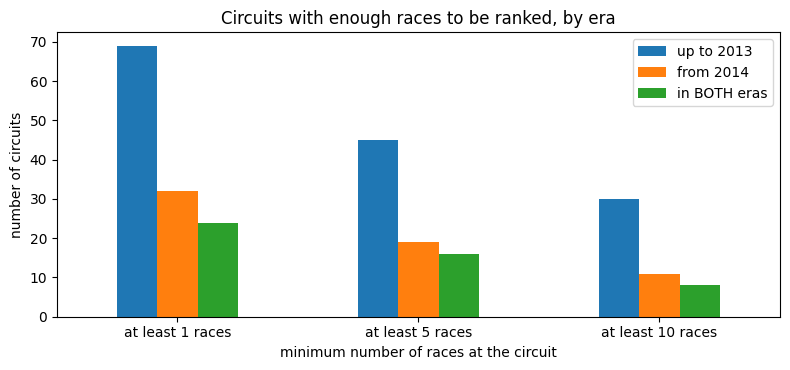

In [5]:
# ------------------------------------------------------------------------------------------
# 1.1  circuits (part b): are they valid, and which ones have enough races to be ranked? (prepares Question 1)
# ------------------------------------------------------------------------------------------
# (a) Structure and sanity of the table itself
print(pk_check("circuits", ["circuitId"]), "| circuitRef unique:", circuits.circuitRef.is_unique, "| name unique:", circuits.name.is_unique)
print("Latitude inside [-90, 90]:", circuits.lat.between(-90, 90).all(), "| longitude inside [-180, 180]:", circuits.lng.between(-180, 180).all())
print("Altitude in metres: lowest", circuits.alt.min(), "| highest", circuits.alt.max(),
      "| circuits at exactly 0 m:", circuits[circuits.alt == 0].circuitRef.tolist())
print("Three lowest altitudes:", circuits.nsmallest(3, "alt")[["circuitRef", "alt"]].values.tolist())

# (b) How many races did each circuit host? (we count the rows of races per circuit)
usage = races.groupby("circuitId").agg(races=("raceId", "size"), first=("year", "min"), last=("year", "max"))
circuit_usage = circuits.merge(usage, left_on="circuitId", right_index=True, how="left")
print("Circuits that never hosted a race:", int(circuit_usage.races.isna().sum()), "| that hosted exactly one race:", int((circuit_usage.races == 1).sum()))
display(circuit_usage.nlargest(5, "races")[["name", "races", "first", "last"]])

# (c) Question 1 compares the era up to 2013 with the era from 2014, so we count races per circuit in each era
n_early = races[races.year <= 2013].groupby("circuitId").size()        # races per circuit, seasons up to 2013
n_modern = races[races.year >= 2014].groupby("circuitId").size()       # races per circuit, seasons from 2014
both = sorted(set(n_early.index) & set(n_modern.index))                # circuits used in BOTH eras
print("Circuits used up to 2013:", len(n_early), "| from 2014:", len(n_modern), "| in both eras:", len(both))
enough = pd.DataFrame({f"at least {k} races": [int((n_early >= k).sum()), int((n_modern >= k).sum()),
                                               int(((n_early.reindex(both) >= k) & (n_modern.reindex(both) >= k)).sum())] for k in [1, 5, 10]},
                      index=["up to 2013", "from 2014", "in BOTH eras"])
display(enough)

# (d) Two traps for the later joins
per_season = races.groupby("year").agg(races=("raceId", "size"), circuits=("circuitId", "nunique"))
print("Seasons in which one circuit hosted two races:", per_season[per_season.races > per_season.circuits].index.tolist())
names_per_circuit = races.groupby("circuitId").name.nunique()          # different Grand Prix names at the same circuit
print("Circuits that hosted Grands Prix under more than one name:", int((names_per_circuit > 1).sum()),
      "| most names at one circuit:", int(names_per_circuit.max()), "->", circuits.set_index("circuitId").name[names_per_circuit.idxmax()])

# Figure: how many circuits are left when we ask for a minimum number of races in each era
enough.T.plot.bar(figsize=(8, 3.8), rot=0, title="Circuits with enough races to be ranked, by era")
plt.xlabel("minimum number of races at the circuit")
plt.ylabel("number of circuits")
save_fig("fig_01_circuits_by_era")

**What we saw**
- `seasons`: 75 rows, `year` unique, every year from 1950 to 2024 present, every season has races. A season has between **7 and 24 races** (fewest in 1950 and 1955, most in 2024). `url` is only a Wikipedia link.
- `circuits`: 77 rows, `circuitId`, `circuitRef` and `name` all unique, coordinates valid, altitude from -7 m (Baku) to 2,227 m. Yeongam and Miami are at exactly 0 m, which could be real or a default.
- Every circuit hosted at least one race and **11 hosted exactly one**. The most used are Monza (74 races), Monaco (70), Silverstone (59) and Spa (57).
- **69 circuits were used up to 2013 but only 32 from 2014**, and only **24 are used in both eras**. Asking for at least 5 races in each era leaves **16 circuits**; at least 10 leaves **8** (Figure 1).
- Two traps: one circuit hosted two races in the same season (2020 and 2021), and 12 circuits hosted Grands Prix under more than one name (the Nürburgring under 4).

**What we learnt**
- Because seasons have 7 to 24 races, anything we count per season (wins, podiums, points) must become a rate or a share.
- For Question 1 the pool of rankable circuits shrinks sharply after 2013, so we need a minimum number of races per circuit in each era. We propose **5 per era (16 circuits)**; the team confirms it in Question 1.
- A circuit is identified by `circuitId` only: never by the race name, and never assume that (`year`, `circuitId`) is a single race.
- `url` is not needed. If altitude is ever used, `alt = 0` should be flagged as possibly unknown.

---

### 1.2 Drivers: which column identifies a driver, and why are `number` and `code` empty?

**Why we look at this.** `drivers` is joined to results, standings, laps, pit stops and sprints, so we must know which column can safely identify a driver. We also want to know why two columns are mostly `\N`: gaps that are random need one treatment, gaps that follow the era need another.

{'table': 'drivers', 'key': 'driverId', 'rows': 861, 'duplicates': 0, 'missing': 0}


,missing,repeated values,usable as identifier
driverId,0,0,True
driverRef,0,0,True
url,0,0,True
code,757,7,False
number,802,11,False
surname,0,59,False


Three-letter codes used by two drivers: 7 | for example: [['ALB', 'Christijan', 'Albers'], ['ALB', 'Alexander', 'Albon'], ['BIA', 'Lucien', 'Bianchi'], ['BIA', 'Jules', 'Bianchi']]
Car numbers used by more than one driver: 11 | surnames shared by several drivers: 45


,drivers,number_missing,code_missing
debut_decade,,,
1950,332,100,100
1960,145,100,100
1970,135,100,100
1980,79,100,100
1990,66,100,82
2000,49,78,27
2010,41,17,0
2020,14,0,0


Drivers who debuted from 2014: with a number 100 % | with a code 100 %


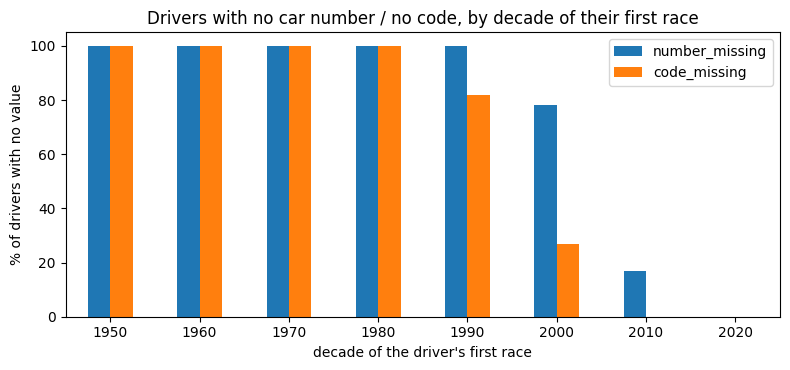

In [6]:
# ------------------------------------------------------------------------------------------
# 1.2  drivers: which column identifies a driver, and why are number and code mostly empty?
# ------------------------------------------------------------------------------------------
print(pk_check("drivers", ["driverId"]))

# (a) Test every column that could identify a driver: a good identifier has no missing value and never repeats
candidates = {"driverId": drivers.driverId, "driverRef": drivers.driverRef, "url": drivers.url, "code": drivers.code,
              "number": drivers.number, "surname": drivers.surname}
display(pd.DataFrame({name: {"missing": int(s.isna().sum()), "repeated values": int(s.dropna().duplicated().sum()),
                             "usable as identifier": bool(s.isna().sum() == 0 and not s.duplicated().any())}
                      for name, s in candidates.items()}).T)
shared_code = drivers[drivers.code.notna() & drivers.code.duplicated(keep=False)].sort_values("code")
print("Three-letter codes used by two drivers:", shared_code.code.nunique(), "| for example:",
      shared_code.head(4)[["code", "forename", "surname"]].values.tolist())
numbers = drivers.number.dropna()
print("Car numbers used by more than one driver:", numbers[numbers.duplicated(keep=False)].nunique(),
      "| surnames shared by several drivers:", drivers.surname[drivers.surname.duplicated()].nunique())

# (b) Why are number and code missing? Is it random, or does it depend on the era?
debut = results.groupby("driverId").year.min()                          # the season of each driver's first race
d = drivers.assign(debut_year=drivers.driverId.map(debut))
d["debut_decade"] = d.debut_year // 10 * 10
missing_by_decade = d.groupby("debut_decade").agg(drivers=("driverId", "size"),
                                                  number_missing=("number", lambda s: round(s.isna().mean() * 100)),   # % without a car number
                                                  code_missing=("code", lambda s: round(s.isna().mean() * 100)))       # % without a 3-letter code
display(missing_by_decade)
recent = d[d.debut_year >= 2014]
print("Drivers who debuted from 2014: with a number", round(recent.number.notna().mean() * 100), "% | with a code", round(recent.code.notna().mean() * 100), "%")

# Figure: missing number / code by the driver's first decade
missing_by_decade[["number_missing", "code_missing"]].plot.bar(figsize=(8, 3.8), rot=0, title="Drivers with no car number / no code, by decade of their first race")
plt.xlabel("decade of the driver's first race")
plt.ylabel("% of drivers with no value")
save_fig("fig_02_drivers_missing_by_era")

**What we saw**
- 861 drivers. Only `number` (802 missing) and `code` (757 missing) contain `\N`.
- Only `driverId`, `driverRef` and `url` can identify a driver. `code` is shared by 7 pairs of drivers (for example ALB is both Albers and Albon), 11 car numbers are reused and 45 surnames are shared.
- The gaps follow the era (Figure 2): every driver who debuted in the 1950s to the 1980s has neither number nor code; for 2000s debutants 78% have no number and 27% no code; **for drivers who debuted from 2014 nothing is missing**. The data shows the pattern; the reason (permanent car numbers were introduced in 2014) is general F1 knowledge that the data does not show.

**What we learnt**
- `driverId` is the only key we use: never `code`, `number` or a name.
- "Missing" here means "did not exist yet in that era", not "lost". We keep these cells missing, never fill them, and do not use them as model inputs (they are labels, and their absence only tells the era).

---

### 1.3 Drivers: dates of birth and the age at every race

**Why we look at this.** "Driver age on the race day" is a feature that is known before the race. For it, every date of birth must be a real date and every age must be possible. This is also our first semantic-typing check: text to date.

dob is now: datetime64[ns] | earliest 1896-12-28 | latest 2005-05-08 | missing: 0
Born on 1 January (a typical placeholder): 7 of 861 | drivers sharing a birthdate with another driver: 36
Age at a race: youngest 17.5 | oldest 58.8 | negative ages: 0 | under 17: 0 | over 55: 4


,surname,year,age
22464,Verstappen,2015,17.5
22483,Verstappen,2015,17.5


,surname,year,age
18999,Chiron,1958,58.8
19389,Chiron,1956,56.8


Drivers born after their first race: 0 | drivers with no race at all: 0
Median driver age: 1950 = 39.0 | 1980 = 30.3 | 2024 = 27.9


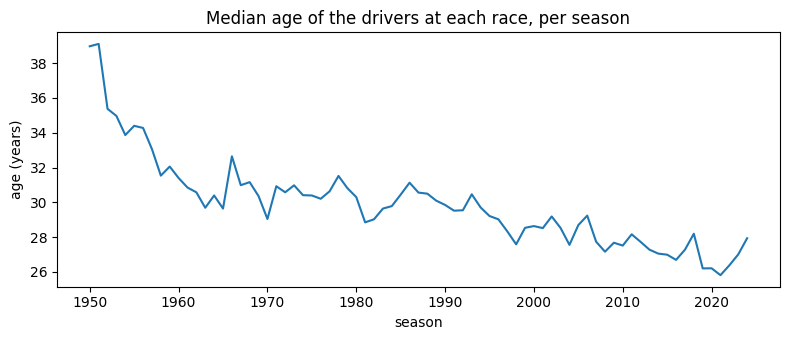

In [7]:
# ------------------------------------------------------------------------------------------
# 1.3  drivers: dates of birth and the age of every driver at every race (a feature we can use before the race)
# ------------------------------------------------------------------------------------------
# (a) Turn the text dates into real dates. errors="raise" stops the notebook if even one date cannot be read.
dob = pd.to_datetime(drivers.dob, format="%Y-%m-%d", errors="raise")
print("dob is now:", dob.dtype, "| earliest", dob.min().date(), "| latest", dob.max().date(), "| missing:", int(dob.isna().sum()))
print("Born on 1 January (a typical placeholder):", int(((dob.dt.month == 1) & (dob.dt.day == 1)).sum()), "of", len(dob),
      "| drivers sharing a birthdate with another driver:", int(dob.duplicated(keep=False).sum()))

# (b) Age on the day of every race: one row per driver per race, race date minus date of birth
entries = (driver_races[["raceId", "driverId"]]
           .merge(races[["raceId", "date", "year"]], on="raceId")
           .merge(drivers[["driverId", "surname"]].assign(dob=dob), on="driverId"))
entries["age"] = (entries.date - entries.dob).dt.days / 365.25
print("Age at a race: youngest", round(entries.age.min(), 1), "| oldest", round(entries.age.max(), 1),
      "| negative ages:", int((entries.age < 0).sum()), "| under 17:", int((entries.age < 17).sum()), "| over 55:", int((entries.age > 55).sum()))
display(entries.nsmallest(2, "age")[["surname", "year", "age"]].round(1))
display(entries.nlargest(2, "age")[["surname", "year", "age"]].round(1))
first_race = entries.groupby("driverId").date.min()
print("Drivers born after their first race:", int((dob.set_axis(drivers.driverId) > first_race.reindex(drivers.driverId)).sum()),
      "| drivers with no race at all:", int(first_race.reindex(drivers.driverId).isna().sum()))

# (c) Did the age of the grid change over the decades?
median_age = entries.groupby("year").age.median()                      # median age of all drivers in each season
print("Median driver age: 1950 =", round(median_age[1950], 1), "| 1980 =", round(median_age[1980], 1), "| 2024 =", round(median_age[2024], 1))
median_age.plot(figsize=(8, 3.5), title="Median age of the drivers at each race, per season")
plt.xlabel("season")
plt.ylabel("age (years)")
save_fig("fig_03_driver_age")

**What we saw**
- All 861 dates of birth read as real dates (the code would stop with an error otherwise), none is missing, from 1896 to 2005. 7 drivers were born on 1 January; if birthdays were spread evenly we would expect about 861 / 365 = 2.4, so this is too few to be a habit of using 1 January for unknown dates.
- Ages at a race run from 17.5 (Verstappen, 2015) to 58.8 (Chiron, 1958). No age is negative, nobody was born after their first race, and every driver has at least one race.
- The median age of the grid fell from 39.0 (1950) to 30.3 (1980) and 27.9 (2024) (Figure 3).

**What we learnt**
- `dob` becomes a real date in the cleaned table, and `driver_age` (age in years on the race date) is a feature we may use before the race.
- The grid got much younger over time, so age behaves differently in different eras: a point for the report's era-sensitivity limitation.

---

### 1.4 Countries and nationalities  *(prepares Question 2)*

**Why we look at this.** Question 2 asks whether drivers podium more often at home. A home race means the driver's nationality matches the circuit's country, so before we can build that match we must know how both sides are written, and whether some races distort it.

In [8]:
# ------------------------------------------------------------------------------------------
# 1.4  (part a) circuit countries vs driver nationalities: can they be matched as written? (prepares Question 2)
# ------------------------------------------------------------------------------------------
# (a) How are the circuit countries written?
races_per_country = races.merge(circuits[["circuitId", "country"]], on="circuitId").groupby("country").size().rename("races")
country_table = circuits.groupby("country").size().rename("circuits").to_frame().join(races_per_country)
abbreviations = [c for c in country_table.index if c.isupper() and len(c) <= 3]                 # UK, USA, UAE ...
print("Different country spellings:", len(country_table), "| abbreviations:", abbreviations)
display(country_table.loc[["USA", "United States"]])                                             # the same country, written twice
usa_merged = circuits.country.replace({"United States": "USA"})                                 # a copy; raw stays untouched
print("After merging 'United States' into 'USA':", usa_merged.nunique(), "countries | USA circuits:", int((usa_merged == "USA").sum()),
      "| USA races:", int(country_table.loc[["USA", "United States"], "races"].sum()))

# (b) Can we join circuit countries to driver nationalities directly? A home race needs "British driver" <-> "UK circuit"
same_words = sorted(set(circuits.country) & set(drivers.nationality))
print("Circuit countries spelled exactly like a driver nationality:", len(same_words), "of", circuits.country.nunique(),
      "| examples of the mismatch: circuits say", ["UK", "Germany", "Monaco"], "| drivers say", ["British", "German", "Monegasque"])

# (c) The nationality column itself
print("Different nationality values:", drivers.nationality.nunique(),
      "| values with stray spaces:", list(drivers.nationality[drivers.nationality != drivers.nationality.str.strip()].unique()))
nationality = drivers.nationality.str.strip().replace({"Argentinian": "Argentine"})              # trim spaces, merge the two spellings
print("After trimming and merging 'Argentinian' into 'Argentine':", nationality.nunique(), "nationalities")

Different country spellings:

 35 | abbreviations: ['UAE', 'UK', 'USA']


,circuits,races
country,,
USA,11,77
United States,1,2


After merging 'United States' into 'USA': 34 countries | USA circuits: 12 | USA races: 79
Circuit countries spelled exactly like a driver nationality: 0 of 35 | examples of the mismatch: circuits say ['UK', 'Germany', 'Monaco'] | drivers say ['British', 'German', 'Monegasque']
Different nationality values: 43 | values with stray spaces: ['Argentinian ']
After trimming and merging 'Argentinian' into 'Argentine': 42 nationalities


Nationalities: 42 | mapped: 25 | their country has no circuit: 13 | mixed or historical (decided in Question 2): ['American-Italian', 'Argentine-Italian', 'East German', 'Rhodesian']
Circuit countries that no driver nationality maps to: ['Azerbaijan', 'Bahrain', 'Korea', 'Morocco', 'Qatar', 'Saudi Arabia', 'Singapore', 'Turkey', 'UAE']
Race entries: 26668 | home entries: 2485 (9.3%)
Indianapolis 500 races: 11 | entries: 381 | of them home entries: 380
American home entries: with the Indy 500 = 500 | without it = 120


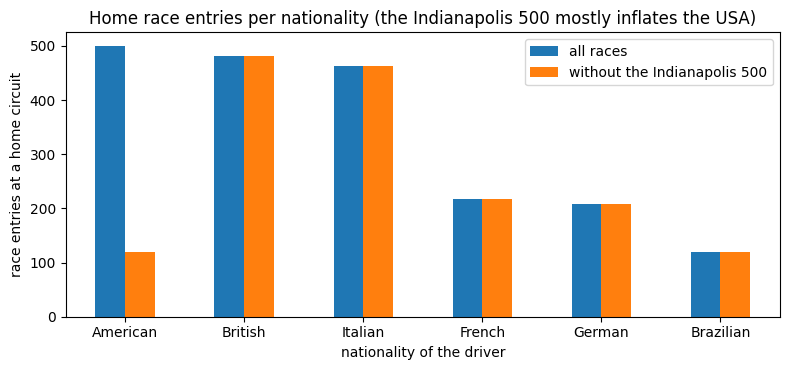

In [9]:
# ------------------------------------------------------------------------------------------
# 1.4  (part b) a written nationality -> country map, and a first look at home races (prepares Question 2)
# ------------------------------------------------------------------------------------------
# The map: a driver's nationality -> the way the SAME country is written in circuits
NAT_TO_COUNTRY = {
    "American": "USA", "Argentine": "Argentina", "Australian": "Australia", "Austrian": "Austria", "Belgian": "Belgium",
    "Brazilian": "Brazil", "British": "UK", "Canadian": "Canada", "Chinese": "China", "Dutch": "Netherlands", "French": "France",
    "German": "Germany", "Hungarian": "Hungary", "Indian": "India", "Italian": "Italy", "Japanese": "Japan", "Malaysian": "Malaysia",
    "Mexican": "Mexico", "Monegasque": "Monaco", "Portuguese": "Portugal", "Russian": "Russia", "South African": "South Africa",
    "Spanish": "Spain", "Swedish": "Sweden", "Swiss": "Switzerland"}
NO_CIRCUIT = {"Chilean", "Colombian", "Czech", "Danish", "Finnish", "Indonesian", "Irish", "Liechtensteiner",
              "New Zealander", "Polish", "Thai", "Uruguayan", "Venezuelan"}                   # their country has no circuit in the data
MIXED = {"American-Italian", "Argentine-Italian", "East German", "Rhodesian"}                  # two countries, or a country that no longer exists
# Safety checks so that the map can never be silently wrong
circuit_countries = set(circuits.country.replace({"United States": "USA"}))
assert set(NAT_TO_COUNTRY.values()) <= circuit_countries, "a mapped country is not spelled like a circuit country"
assert set(NAT_TO_COUNTRY) | NO_CIRCUIT | MIXED == set(nationality), "some nationality is not covered by the map"
print("Nationalities:", nationality.nunique(), "| mapped:", len(NAT_TO_COUNTRY), "| their country has no circuit:", len(NO_CIRCUIT),
      "| mixed or historical (decided in Question 2):", sorted(MIXED))
print("Circuit countries that no driver nationality maps to:", sorted(circuit_countries - set(NAT_TO_COUNTRY.values())))

# A first look: how many race entries are a HOME race? (a driver racing in the country of their nationality)
entries = driver_races[["raceId", "driverId"]].merge(drivers[["driverId"]].assign(nationality=nationality), on="driverId")
race_country = races[["raceId", "circuitId"]].merge(circuits[["circuitId", "country"]], on="circuitId").assign(
    circuit_country=lambda t: t.country.replace({"United States": "USA"}))[["raceId", "circuit_country"]]
entries = entries.merge(race_country, on="raceId")
entries["is_home"] = entries.nationality.map(NAT_TO_COUNTRY) == entries.circuit_country
print("Race entries:", len(entries), "| home entries:", int(entries.is_home.sum()), f"({entries.is_home.mean() * 100:.1f}%)")

# The Indianapolis 500 counted as a championship race in 1950-1960 but almost only Americans entered. Does it distort the numbers?
indy = races.loc[races.name.str.contains("Indianapolis 500"), "raceId"]
entries["indy500"] = entries.raceId.isin(indy)
home_all = entries[entries.is_home].groupby("nationality").size()
home_no_indy = entries[entries.is_home & ~entries.indy500].groupby("nationality").size()
print("Indianapolis 500 races:", len(indy), "| entries:", int(entries.indy500.sum()), "| of them home entries:", int((entries.indy500 & entries.is_home).sum()))
print("American home entries: with the Indy 500 =", int(home_all["American"]), "| without it =", int(home_no_indy["American"]))

# Figure: home entries of the nationalities that have most of them, with and without the Indianapolis 500
top = home_all.sort_values(ascending=False).head(6).index
pd.DataFrame({"all races": home_all[top], "without the Indianapolis 500": home_no_indy.reindex(top)}).plot.bar(
    figsize=(8, 3.8), rot=0, title="Home race entries per nationality (the Indianapolis 500 mostly inflates the USA)")
plt.xlabel("nationality of the driver")
plt.ylabel("race entries at a home circuit")
save_fig("fig_04_home_entries_indy500")

**What we saw**
- The circuits have **35 country spellings**, three of them abbreviations (`UK`, `USA`, `UAE`). The USA is written twice: `USA` (11 circuits, 77 races) and `United States` (1 circuit, 2 races). Merged, there are 34 countries and 12 US circuits.
- **0 of the 35 circuit countries are spelled like a driver nationality**: circuits say "UK", "Germany", "Monaco", drivers say "British", "German", "Monegasque". A direct join would find no home race at all.
- The nationality column has 43 values; `Argentinian ` (with a trailing space) and `Argentine` are the same, which leaves 42.
- Our written map links 25 nationalities to a circuit country; 13 nationalities have no circuit in their country (a home race is impossible); 4 are mixed or historical (American-Italian, Argentine-Italian, East German, Rhodesian). 9 circuit countries have no driver nationality that maps to them.
- With the map, 2,485 of the 26,668 race entries (9.3%) are home races. **The Indianapolis 500 (11 races, 1950 to 1960) has 381 entries and 380 of them are home entries**; without it, the American home entries fall from 500 to 120 (Figure 4).

**What we learnt**
- Question 2 needs an explicit nationality-to-country map, not a join on text. The pairing itself (for example Dutch to Netherlands) is general knowledge that we wrote; the checks in the code only prove that every mapped country is spelled like a circuit country and that every nationality is covered, so the map stays visible in the code for review.
- The Indianapolis 500 inflates the American home races by a factor of about four, so we propose to exclude it from Question 2 (or to report with and without it).
- The 4 mixed or historical nationalities are decided in Question 2.

---

### 1.5 Constructors: is one `constructorId` one continuous team?  *(prepares Question 3 and the team-form feature)*

**Why we look at this.** Question 3 compares constructors, and "team form" will be a feature. Both assume that a constructor is one continuous team. We test whether that is true, and how many constructors are too small to compare.

In [10]:
# ------------------------------------------------------------------------------------------
# 1.5  constructors: is one constructorId one continuous team? (prepares Question 3 and the team-form feature)
# ------------------------------------------------------------------------------------------
print(pk_check("constructors", ["constructorId"]), "| constructorRef unique:", constructors.constructorRef.is_unique, "| name unique:", constructors.name.is_unique)

# (a) How active was each constructor? One row of results = one car in one race.
cars = results[["raceId", "constructorId", "year"]].merge(races[["raceId", "name"]].rename(columns={"name": "race_name"}), on="raceId")
activity = cars.groupby("constructorId").agg(entries=("raceId", "size"), first=("year", "min"), last=("year", "max"))
teams = constructors.merge(activity, left_on="constructorId", right_index=True, how="left")
print("Constructors:", len(teams), "| with no result row:", int(teams.entries.isna().sum()), teams[teams.entries.isna()].name.tolist(),
      "| that raced a single season only:", int((teams["first"] == teams["last"]).sum()),
      "| with 100 or more entries:", int((teams.entries >= 100).sum()))

# (b) Test 1: one real team split over several constructorIds? Constructors with the same Wikipedia page are usually one team with different engines.
same_page = constructors[constructors.url.duplicated(keep=False)].groupby("url").agg(ids=("constructorId", "size"), names=("name", lambda s: ", ".join(sorted(s)[:4])))
print("Constructors that share a Wikipedia page with another constructor:", int(constructors.url.duplicated(keep=False).sum()), "in", len(same_page), "groups")
display(same_page.sort_values("ids", ascending=False).head(4))

# (c) Test 2: one constructorId that covers separate periods, many years apart? (we measure the longest break between seasons)
def longest_break(years):
    years = sorted(years)
    return max([b - a - 1 for a, b in zip(years, years[1:])], default=0)
teams["longest_break_seasons"] = teams.constructorId.map(cars.groupby("constructorId").year.apply(lambda s: longest_break(set(s))))
display(teams[(teams.longest_break_seasons >= 5) & (teams.entries >= 50)].sort_values("entries", ascending=False)[["name", "first", "last", "entries", "longest_break_seasons"]].astype(
    {"first": int, "last": int, "entries": int, "longest_break_seasons": int}))

# (d) The two periods of Question 3, and the constructors that only ever raced the Indianapolis 500
for a, b in [(2014, 2021), (2022, 2024)]:
    print(f"Different constructors in {a}-{b}:", cars[cars.year.between(a, b)].constructorId.nunique())
indy = cars.race_name.str.contains("Indianapolis 500")
only_indy = set(cars[indy].constructorId) - set(cars[~indy].constructorId)
print("Constructors that only ever raced the Indianapolis 500:", len(only_indy), "| their entries:", int(cars.constructorId.isin(only_indy).sum()))

{'table': 'constructors', 'key': 'constructorId', 'rows': 212, 'duplicates': 0, 'missing': 0} | constructorRef unique: True | name unique: True
Constructors: 212 | with no result row: 1 ['Eagle'] | that raced a single season only: 70 | with 100 or more entries: 56
Constructors that share a Wikipedia page with another constructor: 50 in 13 groups


,ids,names
url,,
http://en.wikipedia.org/wiki/Cooper_Car_Company,11,"Cooper, Cooper-ATS, Cooper-Alfa Romeo, Cooper-BRM"
http://en.wikipedia.org/wiki/Team_Lotus,7,"Lotus-BRM, Lotus-Borgward, Lotus-Climax, Lotus-Ford"
http://en.wikipedia.org/wiki/Brabham,6,"Brabham, Brabham-Alfa Romeo, Brabham-BRM, Brabham-Climax"
http://en.wikipedia.org/wiki/De_Tomaso,4,"De Tomaso, De Tomaso-Alfa Romeo, De Tomaso-Ferrari, De Tomaso-Osca"


,name,first,last,entries,longest_break_seasons
31,Team Lotus,1958,1994,871,6
14,Sauber,1993,2024,837,5
3,Renault,1977,2020,787,16
33,Brabham,1962,1992,662,6
129,Mercedes,1954,2024,652,54
20,Arrows,1978,2002,590,6
49,Alfa Romeo,1950,2023,451,33
115,Aston Martin,1959,2024,191,60
25,Lola,1962,1997,165,9
52,ATS,1963,1984,162,14


Different constructors in 2014-2021: 19
Different constructors in 2022-2024: 12
Constructors that only ever raced the Indianapolis 500: 31 | their entries: 176


**What we saw**
- 212 constructors; `constructorId`, `constructorRef` and `name` are unique. One constructor (Eagle) has no result row, **70 raced a single season** and 56 have 100 or more entries.
- **One real team is split over several ids.** 50 constructors share a Wikipedia page with another one, in 13 groups: Cooper has 11 ids (Cooper, Cooper-ATS, Cooper-Alfa Romeo, Cooper-BRM...), Lotus 7, Brabham 6. The names suggest that each new chassis-and-engine pairing got a new id.
- **One id can cover separate periods.** Mercedes appears in 1954 to 2024 with a break of 54 seasons, Alfa Romeo with 33, Aston Martin with 60, Honda with 37, Renault with 16.
- Question 3's periods have **19 constructors (2014 to 2021) and 12 (2022 to 2024)**. 31 constructors only ever raced the Indianapolis 500 (176 entries): chassis builders, not teams.

**What we learnt**
- `constructorId` is a valid key, but it is **not** one continuous team. A team-form feature should use only a recent window (for example the previous 1 or 2 seasons) so that a gap resets the history, plus a count of prior entries; the report must say that renamed teams reset their history.
- For Question 3 we set a minimum number of starts per constructor, mention the renames, and exclude the Indianapolis 500 chassis.

---

### 1.6 Status: the 139 reasons a race ended  *(prepares Question 3)*

**Why we look at this.** Question 3 asks for the mechanical-retirement rate. The brief defines it: a race start that ended early because a component of the car failed, excluding crashes, driver errors and regulation decisions. The `status` table has 139 reasons, so they must be sorted into groups and the unclear ones argued. We also ask whether status is something we could use before the race. We sort the statuses by what the status name says: a named car component is mechanical, crash words are accident or collision, a rules decision is disqualified or excluded, injury or illness is driver health, and when the name does not say which (for example `Retired`) it goes to a grey zone.

{'table': 'status', 'key': 'statusId', 'rows': 139, 'duplicates': 0, 'missing': 0} | status text unique: True
Statuses that mean 'finished, N laps down': 33 | never used: ['+49 Laps', '+38 Laps'] | used 5 times or fewer: 54


,statuses,entries
group,,
finished,1,7674
"finished, laps down",33,7487
mechanical (clear),58,6278
accident or collision,5,2774
did not start,4,1613
grey zone,29,712
disqualified or excluded,3,156
driver health,6,65


period,2014-2021,2022-2024
mechanical (clear only),9.2,5.6
mechanical + grey zone,11.4,7.0
accident or collision,6.6,6.6


Podium finishers whose status is 'finished' or 'finished, laps down': 99.8 %


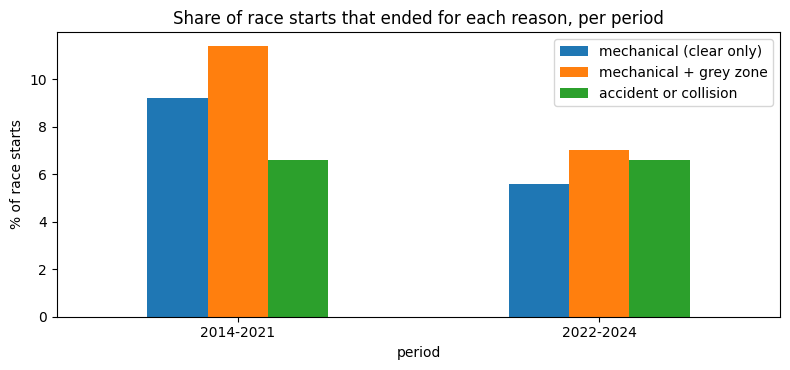

In [11]:
# ------------------------------------------------------------------------------------------
# 1.6  status: 139 reasons a race ended, and a first draft grouping (prepares Question 3)
# ------------------------------------------------------------------------------------------
# Question 3 asks for the mechanical-retirement rate. The brief defines it: "a race start that ended early because a component
# of the car failed. It excludes failures caused by a crash, by the driver, or by a regulation decision."
print(pk_check("status", ["statusId"]), "| status text unique:", status.status.is_unique)

# (a) How often is each status used, in the two periods of Question 3?
uses = results.assign(period=pd.cut(results.year, [2013, 2021, 2024], labels=["2014-2021", "2022-2024"]))
status["uses_all_years"] = status.statusId.map(results.statusId.value_counts()).fillna(0).astype(int)
lapped = status.status.str.match(r"^\+\d+ Laps?$")                                                # "+1 Lap", "+2 Laps"...: finished, laps down
print("Statuses that mean 'finished, N laps down':", int(lapped.sum()), "| never used:", status[status.uses_all_years == 0].status.tolist(),
      "| used 5 times or fewer:", int((status.uses_all_years <= 5).sum()))

# (b) A first DRAFT grouping of all 139 statuses. Not a final answer: the unclear ones ("grey zone") are argued in Question 3.
GROUPS = {
    "did not start": ["Did not qualify", "Did not prequalify", "107% Rule", "Withdrew"],
    "disqualified or excluded": ["Disqualified", "Excluded", "Underweight"],                      # a rules decision, not a failure
    "accident or collision": ["Accident", "Collision", "Collision damage", "Spun off", "Fatal accident"],
    "driver health": ["Injury", "Injured", "Eye injury", "Illness", "Driver unwell", "Physical"],   # the driver, not the car
    "mechanical (clear)": ["Engine", "Gearbox", "Suspension", "Transmission", "Electrical", "Brakes", "Clutch", "Fuel system", "Turbo",
                           "Hydraulics", "Overheating", "Ignition", "Oil leak", "Throttle", "Halfshaft", "Oil pressure", "Fuel pump",
                           "Differential", "Fuel leak", "Steering", "Radiator", "Power Unit", "Wheel bearing", "Injection", "Fuel pressure",
                           "Water leak", "Alternator", "Exhaust", "Chassis", "Mechanical", "Magneto", "Driveshaft", "Axle", "Battery",
                           "Power loss", "Oil pump", "Distributor", "Oil pipe", "Electronics", "Water pressure", "Water pump", "ERS",
                           "Supercharger", "Technical", "Pneumatics", "Fuel pipe", "Spark plugs", "Water pipe", "Drivetrain", "Track rod",
                           "Oil line", "Engine fire", "Engine misfire", "Crankshaft", "CV joint", "Cooling system", "Launch control", "Brake duct"],
    "grey zone": ["Retired", "Not classified", "Out of fuel", "Wheel", "Wheel nut", "Wheel rim", "Tyre", "Puncture", "Tyre puncture",
                  "Handling", "Heat shield fire", "Fire", "Vibrations", "Broken wing", "Rear wing", "Front wing", "Undertray", "Damage",
                  "Debris", "Fuel", "Fuel rig", "Refuelling", "Stalled", "Seat", "Driver Seat", "Safety belt", "Safety", "Safety concerns",
                  "Not restarted"]}                                  # could be a failure OR a crash, a team error, or no cause given
group_of = {s: g for g, members in GROUPS.items() for s in members}
status["group"] = [("finished" if s == "Finished" else "finished, laps down" if lapped[i] else group_of.get(s))
                   for i, s in zip(status.index, status.status)]
assert status.group.notna().all(), "some status is not placed in a group"                          # all 139 must be placed
display(status.groupby("group").agg(statuses=("status", "size"), entries=("uses_all_years", "sum")).sort_values("entries", ascending=False))

# (c) How much does the unclear group change the answer to Question 3? We count race starts (everyone who did not start is left out).
starts = uses.merge(status[["statusId", "group"]], on="statusId")
starts = starts[(starts.group != "did not start") & starts.period.notna()]
share = (starts.groupby("period", observed=True).group.value_counts(normalize=True).unstack(0) * 100).round(1)
rates = pd.DataFrame({"mechanical (clear only)": share.loc["mechanical (clear)"],
                      "mechanical + grey zone": share.loc["mechanical (clear)"] + share.loc["grey zone"],
                      "accident or collision": share.loc["accident or collision"]})
display(rates.T)                                                                                   # % of race starts, per period

# (d) Status is only known AFTER the race. How much of the podium does it give away?
podium = results[results.positionOrder <= 3]
podium_status = podium.statusId.map(status.set_index("statusId").group)
print("Podium finishers whose status is 'finished' or 'finished, laps down':", round(podium_status.isin(["finished", "finished, laps down"]).mean() * 100, 1), "%")

# Figure: the sensitivity of the Question 3 rate to the grey zone
rates.plot.bar(figsize=(8, 3.8), rot=0, title="Share of race starts that ended for each reason, per period")
plt.xlabel("period")
plt.ylabel("% of race starts")
save_fig("fig_05_status_groups")

**What we saw**
- 139 different statuses; 33 of them mean "finished, N laps down", 54 are used 5 times or fewer, and 2 are never used (`+49 Laps`, `+38 Laps`).
- Our first draft sorts all 139 into groups: 58 clearly mechanical, 5 accident or collision, and **29 in a grey zone** (for example `Retired`, `Wheel`, `Tyre`, `Puncture`) that could be a failure or something else.
- **In 2014 to 2021, 9.2% of race starts ended for a clearly mechanical reason; in 2022 to 2024, 5.6%.** If the whole grey zone counted as mechanical, the rates would be 11.4% and 7.0% (Figure 5). Accidents and collisions are 6.6% in both periods.
- 99.8% of the podium finishers have the status `Finished` or `+N Laps`: the status is essentially the race outcome.

**What we learnt**
- The grouping is a draft for Question 3, where each grey status is argued against the brief's definition. Because the answer depends on the grey zone, Question 3 reports both definitions and says which one is the headline.
- `statusId` is known only after the race: it is **never** a feature. We use it for Question 3 and, from earlier races only, for retirement rates.

---
## Part 2 · Race-level tables

`sprint_results`, `driver_standings`, `constructor_standings` and `constructor_results` summarise what happened in or after a race. For each of them the key question is *when is it written*, and therefore *can it be known before the race?* The brief treats results, points and post-race standings as leakage, so we answer this with evidence, not with assumptions.

### 2.1 sprint_results: what is in it, and is it a useful feature?

**Why we look at this.** `sprint_results` looks like a small copy of `results`, but only for the short Saturday sprint races (2021 onward). A sprint is run before the Sunday race, so in time it is allowed. But is it complete enough, what do its odd columns mean, and does it add anything that the Sunday grid does not already give us?

In [12]:
# ------------------------------------------------------------------------------------------
# 2.1  (part a) sprint_results: what is in it, how many races does it cover, and why are some cells empty?
# ------------------------------------------------------------------------------------------
print(pk_check("sprint_results", ["resultId"]), "|", pk_check("sprint_results", ["raceId", "driverId"])["duplicates"], "duplicate (raceId, driverId)")
per_sprint = sprint.groupby("raceId").size()
print("Rows:", len(sprint), "| different sprints:", len(per_sprint), "| rows per sprint:", per_sprint.value_counts().to_dict())
order = sprint.groupby("raceId").positionOrder.agg(["min", "max", "nunique", "size"])               # the finishing order should run 1..20
print("Finishing order is exactly 1..n in every sprint:", bool(((order["min"] == 1) & (order["max"] == order["size"]) & (order["nunique"] == order["size"])).all()))

# (a) Which races had a sprint?
coverage = pd.DataFrame({"races": races[races.year >= 2021].groupby("year").size(), "with a sprint": sprint.groupby("year").raceId.nunique()}).fillna(0).astype(int)
coverage["share %"] = (coverage["with a sprint"] / coverage["races"] * 100).round(0)
display(coverage)
print("Share of ALL", len(races), "races that have a sprint:", round(len(per_sprint) / len(races) * 100, 1), "%",
      "| same sprints as races.sprint_date says:", set(sprint.raceId) == set(races[races.sprint_date.notna()].raceId))
main = sprint[["raceId", "driverId", "constructorId"]].merge(results[["raceId", "driverId", "constructorId"]], on=["raceId", "driverId"], how="left", suffixes=("", "_race"))
sprint_day = races[races.sprint_date.notna()].assign(days_before=lambda t: (t.date - pd.to_datetime(t.sprint_date)).dt.days)
print("Days between a sprint and its Sunday race:", sprint_day.days_before.value_counts().to_dict())            # tells us whether the sprint is known before the race
print("Sprinters with no row in the main race:", int(main.constructorId_race.isna().sum()), "| driving for another team in the main race:", int((main.constructorId != main.constructorId_race).sum()))

# (b) Why are some cells empty? We look at how the sprint ended for those drivers.
outcome = sprint.statusId.map(status.set_index("statusId").status)
empty = pd.DataFrame({col: [int(sprint[col].isna().sum()), int((sprint[col].isna() & (outcome == "Finished")).sum())]
                      for col in ["position", "time", "milliseconds", "fastestLap", "fastestLapTime"]}, index=["empty cells", "of them for a driver who Finished"]).T
display(empty)

# (c) The time column is text ("25:38.426" for the winner, "+1.430" for the others). Can we turn it into numbers and trust it?
def sprint_time_to_ms(t):
    parts = t.lstrip("+").split(":")
    return round((float(parts[-2]) * 60 + float(parts[-1]) if len(parts) > 1 else float(parts[-1])) * 1000)
timed = sprint.dropna(subset=["time"]).copy()
timed["text_ms"] = timed.time.map(sprint_time_to_ms)
winner_ms = timed[~timed.time.str.startswith("+")].set_index("raceId").text_ms                         # the winner's time in each sprint
timed["expected_ms"] = np.where(timed.time.str.startswith("+"), timed.raceId.map(winner_ms) + timed.text_ms, timed.text_ms)   # a gap is added to the winner's time
print("Rows where the time text agrees with the milliseconds column:", int((timed.expected_ms == timed.milliseconds).sum()), "of", len(timed))

{'table': 'sprint_results', 'key': 'resultId', 'rows': 360, 'duplicates': 0, 'missing': 0} | 0 duplicate (raceId, driverId)
Rows: 360 | different sprints: 18 | rows per sprint: {20: 18}
Finishing order is exactly 1..n in every sprint: True


,races,with a sprint,share %
year,,,
2021,22,3,14.0
2022,22,3,14.0
2023,22,6,27.0
2024,24,6,25.0


Share of ALL 1125 races that have a sprint: 1.6 % | same sprints as races.sprint_date says: True
Days between a sprint and its Sunday race: {1: 18}
Sprinters with no row in the main race: 0 | driving for another team in the main race: 0


,empty cells,of them for a driver who Finished
position,15,0
time,20,0
milliseconds,20,0
fastestLap,9,0
fastestLapTime,9,0


Rows where the time text agrees with the milliseconds column: 340 of 340


positionOrder,1,2,3,4,5,6,7,8,9
year,,,,,,,,,
2021,3,2,1,0,0,0,0,0,0
2022,8,7,6,5,4,3,2,1,0
2023,8,7,6,5,4,3,2,1,0
2024,8,7,6,5,4,3,2,1,0


Same points for the same place within a season: True | rows with grid 0 (a pit-lane start): 11


,sprint finish vs Sunday grid,qualifying vs Sunday grid
2021,0.89,0.83
2022,0.99,0.72
2023,0.62,0.99
2024,0.54,0.96


Sprint top 3 who also finished on the Sunday podium: 33 of 54 | Sunday grid top 3 who finished on the podium (same weekends): 30 of 53


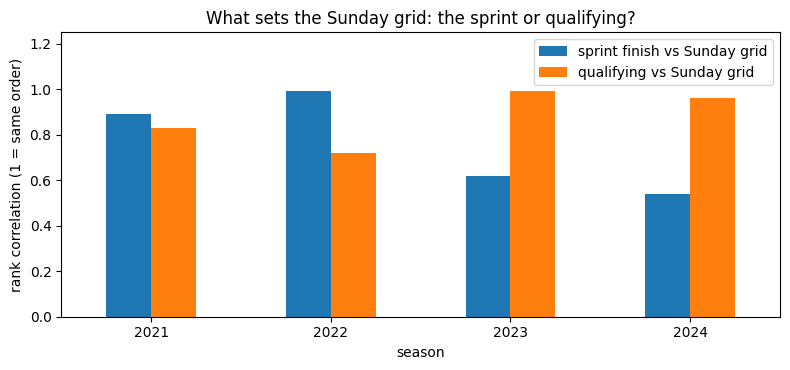

In [13]:
# ------------------------------------------------------------------------------------------
# 2.1  (part b) sprint_results: points rules, and is the sprint a useful feature for Sunday's podium?
# ------------------------------------------------------------------------------------------
# (a) The points rules: the points given for each finishing place, per season
points_rules = sprint[sprint.positionOrder <= 9].pivot_table(index="year", columns="positionOrder", values="points", aggfunc="max").astype(int)
display(points_rules)
print("Same points for the same place within a season:", bool((sprint.groupby(["year", "positionOrder"]).points.nunique() == 1).all()),
      "| rows with grid 0 (a pit-lane start):", int((sprint.grid == 0).sum()))

# (b) A sprint is on Saturday, so its result is known before the Sunday race. But does it add anything we do not already have?
# We compare three orderings of the drivers: the sprint finish, the qualifying position, and the Sunday starting grid.
# (qualifying belongs to our teammates; we only read it here, read-only, for this comparison)
quali = as_num(pd.read_csv(f"{DATA_DIR}/qualifying.csv", dtype=str, keep_default_na=False))[["raceId", "driverId", "position"]].rename(columns={"position": "quali_pos"})
both = (sprint[["raceId", "driverId", "year", "positionOrder"]]
        .merge(results[["raceId", "driverId", "grid", "positionOrder"]], on=["raceId", "driverId"], suffixes=("_sprint", "_race"))
        .merge(quali, on=["raceId", "driverId"], how="left"))
both = both[both.grid > 0]                                              # leave out the pit-lane starters
def agreement(a, b):
    return a.rank().corr(b.rank())                                       # rank correlation: 1 = same order, 0 = unrelated
by_year = pd.DataFrame({"sprint finish vs Sunday grid": {y: agreement(g.positionOrder_sprint, g.grid) for y, g in both.groupby("year")},
                        "qualifying vs Sunday grid": {y: agreement(g.quali_pos, g.grid) for y, g in both.groupby("year")}}).round(2)
display(by_year)
top3 = both[both.positionOrder_sprint <= 3]
print("Sprint top 3 who also finished on the Sunday podium:", int((top3.positionOrder_race <= 3).sum()), "of", len(top3),
      "| Sunday grid top 3 who finished on the podium (same weekends):", int((both[both.grid <= 3].positionOrder_race <= 3).sum()), "of", int((both.grid <= 3).sum()))

by_year.plot.bar(figsize=(8, 3.8), rot=0, title="What sets the Sunday grid: the sprint or qualifying?")
plt.xlabel("season")
plt.ylabel("rank correlation (1 = same order)")
plt.ylim(0, 1.25)
save_fig("fig_06_sprint_vs_grid")

**What we saw**
- 360 rows = **18 sprints** with exactly 20 rows each and a finishing order of 1 to 20 in every sprint; (`raceId`, `driverId`) is unique; they are the same 18 races that `races.sprint_date` lists; every sprinter also raced on Sunday for the same team. **Every sprint is held exactly 1 day before its Sunday race (18 of 18)**, so its result is known before the race.
- It covers **1.6% of all races** (3, 3, 6 and 6 sprints in 2021 to 2024, which is 14%, 14%, 27% and 25% of those seasons).
- The empty cells belong to drivers who did not finish: 15 rows have no position and 20 have no time, and none of them finished the sprint. The `time` text ("25:38.426" for the winner, "+1.430" for the others) equals the numeric `milliseconds` in all 340 of the 340 rows that have a time.
- Points: the top 3 scored 3-2-1 in 2021; the top 8 scored 8 to 1 from 2022. 11 rows have `grid` 0, which is a pit-lane start.
- **Overlap with the Sunday grid (Figure 6).** In 2021 and 2022 the sprint finishing order is almost the Sunday grid (rank correlation 0.89 and 0.99) while qualifying is less close (0.83 and 0.72). From 2023 qualifying sets the grid (0.99 and 0.96) and the sprint overlaps much less (0.62 and 0.54). The sprint's top 3 reached the Sunday podium 33 times out of 54; the Sunday grid's top 3 did it 30 times out of 53 on the same weekends.

**What we learnt**
- `\N` is read as missing, `milliseconds` is used instead of the `time` text, and the empty cells are not filled (they mean "did not finish").
- A sprint feature would be empty for 98% of the races and, in 2021 and 2022, it repeats the Sunday grid without adding podium signal. We therefore propose **not to use it in the main model**, at most as an optional experiment with a `has_sprint` flag. The team decides (open decision 1).
- Sprint points are inside the standings and the team scores of 2021 onward, which matters in steps 2.3 to 2.5.

---

### 2.2 driver_standings: what is one row, and where does it look odd?

**Why we look at this.** `driver_standings` is the championship table after each race, which makes it a tempting feature ("points so far"). It is only usable if we know exactly what a row contains, whether every driver has one, and which values look strange. Step 2.3 then tests when a row is written.

In [14]:
# ------------------------------------------------------------------------------------------
# 2.2  driver_standings: what is one row, and where does it look odd?
# ------------------------------------------------------------------------------------------
ds = driver_st.merge(races[["raceId", "round", "name"]], on="raceId").sort_values(["year", "driverId", "round"])    # one driver's season in race order
print(pk_check("driver_standings", ["driverStandingsId"]), "|", pk_check("driver_standings", ["raceId", "driverId"])["duplicates"], "duplicate (raceId, driverId)")
print("Races without any standings:", len(set(races.raceId) - set(ds.raceId)), "of", len(races))

# (a) Is a row "who raced today" or a running total? We compare the rows of each race with the drivers who really started it.
rows_per_race = pd.DataFrame({"standings rows": ds.groupby("raceId").size(), "starters": driver_races.groupby("raceId").size()})
rows_per_race["decade"] = rows_per_race.index.map(YEAR) // 10 * 10
display(rows_per_race.groupby("decade").median().astype(int).T)
compare = ds[["raceId", "driverId"]].merge(driver_races[["raceId", "driverId"]].assign(started=1), on=["raceId", "driverId"], how="outer", indicator=True)
print("Standings rows for a driver who did NOT start that race:", int((compare._merge == "left_only").sum()),
      "| race starters with NO standings row:", int((compare._merge == "right_only").sum()))
ds["added"] = ds.groupby(["year", "driverId"]).points.diff().fillna(ds.points)                          # points added by this one race
ds["wins_added"] = ds.groupby(["year", "driverId"]).wins.diff().fillna(ds.wins)
ds["round_jump"] = ds.groupby(["year", "driverId"])["round"].diff()
print("Inside a season, points ever go DOWN:", int((ds.added < 0).sum()), "| wins ever go down:", int((ds.wins_added < 0).sum()),
      "| a driver skips a round and comes back:", int((ds.round_jump > 1).sum()))

# (b) position, positionText and points
order = ds.groupby("raceId").position.agg(["min", "max", "nunique", "size"])                            # positions should run 1..n with no repeats
print("position is exactly 1..n in", int(((order["min"] == 1) & (order["max"] == order["size"]) & (order["nunique"] == order["size"])).sum()), "of", len(order), "races")
odd = ds[pd.to_numeric(ds.positionText, errors="coerce") != ds.position]                                # text that is not the same number as position
display(odd[["year", "round", "name", "driverId", "points", "position", "positionText"]])
print("Rows with a decimal in points:", int((ds.points % 1 != 0).sum()), "| caused by", ds[ds.added % 1 != 0].groupby(["year", "round"]).ngroups, "races, in seasons",
      sorted(ds[ds.added % 1 != 0].year.unique().tolist()))
# Why decimals? We compare the winner's points in those races with the usual winner points of the same season.
decimal_races = ds[ds.added % 1 != 0].groupby(["raceId", "year", "round", "name"]).size().reset_index()[["raceId", "year", "round", "name"]]
winners_points = results[results.positionOrder == 1]
decimal_races["winner_points"] = decimal_races.raceId.map(winners_points.groupby("raceId").points.max())
decimal_races["usual_winner_points"] = decimal_races.year.map(winners_points.groupby("year").points.agg(lambda s: s.mode().iloc[0]))
display(decimal_races[decimal_races.year >= 1960][["year", "round", "name", "winner_points", "usual_winner_points"]])
early = decimal_races[decimal_races.year < 1960]
print("Decimal-point races before 1960:", len(early), "| of them with a repeated driver-race, i.e. a shared car (step 0.2):", int(early.raceId.isin(set(repeated.reset_index().raceId)).sum()))

# (c) Which race starters have no standings row? (we look at it by decade)
starts = driver_races[["raceId", "driverId", "year", "points"]].merge(ds[["raceId", "driverId"]].assign(has_row=1), on=["raceId", "driverId"], how="left")
starts["has_row"] = starts.has_row.fillna(0).astype(bool)
no_row = starts[~starts.has_row]
print("Race starts with no standings row:", len(no_row), "| by decade (%):", ((1 - starts.groupby(starts.year // 10 * 10).has_row.mean()) * 100).round(1).to_dict(),
      "| in the 1990s and 2000s:", int((no_row.year // 10 * 10).isin([1990, 2000]).sum()))
print("Race starts that SCORED points but have no standings row:", int((~starts.has_row & (starts.points > 0)).sum()), "of", int((starts.points > 0).sum()))

# (d) Points are not comparable between seasons: the champion's final total
last_round = races.sort_values("round").groupby("year").raceId.last()
champion = ds[ds.raceId.isin(last_round) & (ds.position == 1)].set_index("year").points
print("Champion's final points: 1950 =", champion[1950], "| 2009 =", champion[2009], "| 2010 =", champion[2010], "| 2023 =", champion[2023])

{'table': 'driver_standings', 'key': 'driverStandingsId', 'rows': 34863, 'duplicates': 0, 'missing': 0} | 0 duplicate (raceId, driverId)
Races without any standings: 0 of 1125


decade,1950,1960,1970,1980,1990,2000,2010,2020
standings rows,71,33,37,32,26,22,22,21
starters,21,20,26,28,26,20,22,20


Standings rows for a driver who did NOT start that race: 8664 | race starters with NO standings row: 469
Inside a season, points ever go DOWN: 0 | wins ever go down: 0 | a driver skips a round and comes back: 0
position is exactly 1..n in 1125 of 1125 races


,year,round,name,driverId,points,position,positionText
4375,1997,17,European Grand Prix,30,78.0,26,D


Rows with a decimal in points: 276 | caused by 22 races, in seasons [1952, 1953, 1954, 1955, 1956, 1959, 1975, 1984, 1991, 2009, 2021]


,year,round,name,winner_points,usual_winner_points
0,2009,2,Malaysian Grand Prix,5.0,10.0
1,1991,16,Australian Grand Prix,5.0,10.0
2,1984,6,Monaco Grand Prix,4.5,9.0
3,1975,4,Spanish Grand Prix,4.5,9.0
4,1975,12,Austrian Grand Prix,4.5,9.0
21,2021,12,Belgian Grand Prix,12.5,25.0


Decimal-point races before 1960: 16 | of them with a repeated driver-race, i.e. a shared car (step 0.2): 10
Race starts with no standings row: 469 | by decade (%): {1950: 0.1, 1960: 0.1, 1970: 0.1, 1980: 0.2, 1990: 7.0, 2000: 4.1, 2010: 0.1, 2020: 0.0} | in the 1990s and 2000s: 447
Race starts that SCORED points but have no standings row: 0 of 8167
Champion's final points: 1950 = 30.0 | 2009 = 95.0 | 2010 = 256.0 | 2023 = 575.0


**What we saw**
- 34,863 rows, both keys unique, nothing missing, and all 1,125 races have standings.
- **A row is a running total, not "who raced today".** The median race has 71 standings rows for 21 starters in the 1950s, and 21 rows for 20 starters in the 2020s. 8,664 rows belong to a driver who did not start that race but had raced earlier in the season. Inside a season points never go down, wins never go down, and no driver skips a round.
- `position` runs exactly 1 to n in all 1,125 races. One row has `positionText` `D`: Michael Schumacher, 1997 European GP, with 78 points but position 26 (last). The data shows only the `D` and the last place; that it was a disqualification from that championship is F1 history.
- 276 rows have decimal points, caused by only 22 races. In the 6 races from 1975 on, the winner got exactly half of the usual points (4.5 instead of 9, 5 instead of 10, 12.5 instead of 25). Before 1960 there are 16 such races and 10 of them contain a shared car from step 0.2; for the other 6 the data does not show the reason.
- **469 race starts have no standings row**, 447 of them in the 1990s and 2000s (7.0% of the starts of the 1990s and 4.1% of the 2000s, 0.2% or less in other decades). But **every start that scored points has a row (0 of 8,167)**.
- The champion's final points go from 30 (1950) to 95 (2009), 256 (2010) and 575 (2023).

**What we learnt**
- `position` stays numeric and `positionText` is ignored; points are decimals, not integers.
- A missing standings row can only mean "no points yet": it gets 0 points and 0 wins before the race, but its position is unknown, never 0.
- Raw points are not comparable across seasons, so features use the position, the gap to the leader or the share of the leader's points.

---

### 2.3 driver_standings: is a row written before or after its race?  *(the key leakage question)*

**Why we look at this.** The brief calls current-race results, points and post-race standings data leakage. The row stored under a `raceId` could be the standings before that race or after it, and the table does not say which. We test it: if a row is written after its race, the points it adds must equal what the driver scored that weekend (Sunday race plus sprint). If so, we build the safe version and measure how much the unsafe one would leak. To measure how much a row leaks we use a rank correlation: for each race we rank the drivers by their standing points and compare that ranking with the finishing order (1 means the same order, 0 means unrelated). We use ranks because points are on different scales in different seasons.

Standings rows: 34863 | points added = points scored that weekend: 34781 (99.8%) | drivers who did not start add 0 points: 8664 of 8664
Agreement by decade (%): {1950: 99.4, 1960: 99.5, 1970: 99.8, 1980: 99.7, 1990: 100.0, 2000: 100.0, 2010: 100.0, 2020: 100.0}
Seasons 2021-2024: points added = Sunday points only: 93.2 % | = Sunday + sprint points: 100.0 %
The rows that disagree are all between 1950 and 1990
Driver-seasons whose final standing is LOWER than the points scored: 50 | in seasons 1950 to 1990 | HIGHER: 0


,surname,year,points scored,final standing
0,Clark,1963,73.0,54.0
1,Prost,1988,105.0,87.0


raceId order equals date order: False | raceIds whose date is earlier than the previous raceId: 61


Race starts in round 1 (no standings before them): 1721 of 26668 | after round 1: standings-before equals the points scored in earlier races: 99.75 %


,1950,1960,1970,1980,1990,2000,2010,2020
before the race,0.35,0.33,0.36,0.40,0.42,0.48,0.61,0.60
after the race (leak),0.55,0.53,0.49,0.51,0.51,0.57,0.67,0.66


Average rank correlation over all races: {'before the race': 0.46, 'after the race (leak)': 0.57}
The race winner leads the standings AFTER the race in 48.4 % of races, but led them BEFORE the race in 32.8 % (round 2 onward)


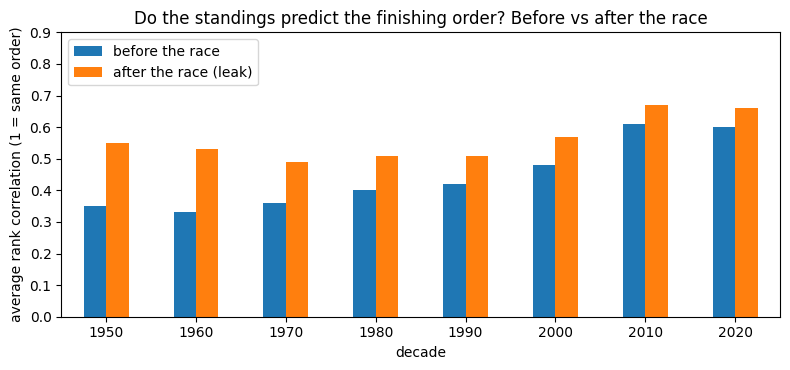

In [15]:
# ------------------------------------------------------------------------------------------
# 2.3  driver_standings: is a row written BEFORE or AFTER its race? (the key leakage question)
# ------------------------------------------------------------------------------------------
# What did each driver score in each race? The Sunday race points plus the Saturday sprint points of the same weekend.
scored = driver_races[["raceId", "driverId", "year", "positionOrder", "points"]].rename(columns={"points": "race_points"})
scored = scored.merge(sprint[["raceId", "driverId", "points"]].rename(columns={"points": "sprint_points"}), on=["raceId", "driverId"], how="left")
scored["sprint_points"] = scored.sprint_points.fillna(0)
scored["scored"] = scored.race_points + scored.sprint_points

# (a) If a row is written AFTER its race, the points it adds must equal what the driver scored that weekend.
m = ds.merge(scored[["raceId", "driverId", "race_points", "sprint_points", "scored", "positionOrder"]], on=["raceId", "driverId"], how="left")
m[["race_points", "sprint_points", "scored"]] = m[["race_points", "sprint_points", "scored"]].fillna(0)
m["same_as_sunday"] = (m.added - m.race_points).abs() < 1e-6
m["same_as_weekend"] = (m.added - m.scored).abs() < 1e-6
print("Standings rows:", len(m), "| points added = points scored that weekend:", int(m.same_as_weekend.sum()), f"({m.same_as_weekend.mean() * 100:.1f}%)",
      "| drivers who did not start add 0 points:", int(((m.positionOrder.isna()) & (m.added == 0)).sum()), "of", int(m.positionOrder.isna().sum()))
print("Agreement by decade (%):", (m.groupby(m.year // 10 * 10).same_as_weekend.mean() * 100).round(1).to_dict())
since_2021 = m[m.year >= 2021]
print("Seasons 2021-2024: points added = Sunday points only:", round(since_2021.same_as_sunday.mean() * 100, 1), "% | = Sunday + sprint points:", round(since_2021.same_as_weekend.mean() * 100, 1), "%")
print("The rows that disagree are all between", int(m[~m.same_as_weekend].year.min()), "and", int(m[~m.same_as_weekend].year.max()))
# Some drivers' final standing is LOWER than the points they scored (in those years only a driver's best results counted). The biggest gaps:
season_total = scored.groupby(["year", "driverId"]).scored.sum()                                      # all points a driver scored in a season
final_row = ds.sort_values("round").groupby(["year", "driverId"]).tail(1).set_index(["year", "driverId"]).points
gap = final_row - season_total.reindex(final_row.index).fillna(0)
print("Driver-seasons whose final standing is LOWER than the points scored:", int((gap < -1e-6).sum()), "| in seasons", int(gap[gap < -1e-6].index.get_level_values(0).min()), "to",
      int(gap[gap < -1e-6].index.get_level_values(0).max()), "| HIGHER:", int((gap > 1e-6).sum()))
big = pd.DataFrame({"points scored": season_total.reindex(gap.nsmallest(2).index), "final standing": final_row.reindex(gap.nsmallest(2).index)}).reset_index().merge(drivers[["driverId", "surname"]], on="driverId")
display(big[["surname", "year", "points scored", "final standing"]])

# (b) The SAFE version: the standings from BEFORE the race = the driver's row from the previous round of the same season.
# We shift by season + round, never by raceId. Is raceId in date order?
by_id = races.sort_values("raceId")
print("raceId order equals date order:", bool((by_id.raceId.values == races.sort_values("date").raceId.values).all()),
      "| raceIds whose date is earlier than the previous raceId:", int((by_id.date < by_id.date.shift(1)).sum()))
after = ds[["year", "driverId", "round", "points"]].rename(columns={"points": "points_after"})
before = after.assign(round=after["round"] + 1).rename(columns={"points_after": "points_before"})      # the row of round r-1 is the "before" of round r
x = scored.merge(races[["raceId", "round"]], on="raceId").sort_values(["year", "driverId", "round"])
x["scored_before"] = x.groupby(["year", "driverId"]).scored.cumsum() - x.scored                      # points scored in this driver's earlier races
x = x.merge(after, on=["year", "driverId", "round"], how="left").merge(before, on=["year", "driverId", "round"], how="left")
x[["points_after", "points_before"]] = x[["points_after", "points_before"]].fillna(0)                 # no row yet = no points yet
later = x[x["round"] > 1].copy()                                                                      # round 1 has no earlier standings
print("Race starts in round 1 (no standings before them):", int((x["round"] == 1).sum()), "of", len(x),
      "| after round 1: standings-before equals the points scored in earlier races:", round(((later.points_before - later.scored_before).abs() < 1e-6).mean() * 100, 2), "%")

# (c) How much would the same-race standings leak? For every race: does the ranking by points agree with the finishing order?
def rank_corr(a, b):
    return np.nan if a.nunique() < 2 or b.nunique() < 2 else a.corr(b)                                # undefined when nobody has points yet
later["rank_before"] = later.groupby("raceId").points_before.rank(ascending=False)
later["rank_after"] = later.groupby("raceId").points_after.rank(ascending=False)
later["finish"] = later.groupby("raceId").positionOrder.rank()
leak = pd.DataFrame({"before the race": {r: rank_corr(g.rank_before, g["finish"]) for r, g in later.groupby("raceId")},
                     "after the race (leak)": {r: rank_corr(g.rank_after, g["finish"]) for r, g in later.groupby("raceId")}}).dropna()
by_decade = leak.groupby(leak.index.map(YEAR) // 10 * 10).mean().round(2)
display(by_decade.T)
print("Average rank correlation over all races:", leak.mean().round(2).to_dict())
leader_after = ds[ds.position == 1].set_index("raceId").driverId                                      # the standings leader after each race
prev_race = races.sort_values(["year", "round"]).assign(prev=lambda t: t.groupby("year").raceId.shift(1)).set_index("raceId").prev
winners = results[results.positionOrder == 1].groupby("raceId").driverId.agg(set)
after_ok = [leader_after[r] in winners[r] for r in winners.index]
before_ok = [leader_after[prev_race[r]] in winners[r] for r in winners.index if pd.notna(prev_race[r])]
print("The race winner leads the standings AFTER the race in", round(np.mean(after_ok) * 100, 1), "% of races, but led them BEFORE the race in",
      round(np.mean(before_ok) * 100, 1), "% (round 2 onward)")

by_decade.plot.bar(figsize=(8, 3.8), rot=0, title="Do the standings predict the finishing order? Before vs after the race")
plt.xlabel("decade")
plt.ylabel("average rank correlation (1 = same order)")
plt.ylim(0, 0.9)
plt.legend(loc="upper left")
save_fig("fig_07_standings_leak")

**What we saw**
- **The standings are written after the race, and they include the sprint.** The points a row adds equal the points the driver scored that weekend in **34,781 of 34,863 rows (99.8%)**, and in 100% of the rows from 1991 on. In 2021 to 2024 the Sunday points alone match only 93.2% of the rows, Sunday plus sprint match 100%. Drivers who did not start add 0 points (8,664 of 8,664).
- The 82 rows that disagree are between 1950 and 1990. In those years 50 driver-seasons end *below* what the driver scored, for example Clark 1963 (73 scored, 54 official) and Prost 1988 (105 scored, 87 official). This is consistent with the old rule, known from F1 history, that only a driver's best results counted.
- **The safe version works.** The driver's row from the previous round of the same season equals the points scored in earlier races in 99.75% of the starts after round 1. The 1,721 round-1 starts (6.5%) have no standings before them.
- **`raceId` is not in date order**: 61 ids have an earlier date than the id before them. Inside a season, `round` is in date order.
- **The leak is large (Figure 7).** Ranking the drivers by their standings points agrees with the finishing order at a rank correlation of **0.46 on average with the standings from before the race, but 0.57 with the standings from the same race** (1950s: 0.35 against 0.55; 2010s: 0.61 against 0.67). The race winner leads the standings after the race in 48.4% of the races, but led them before it in only 32.8% (round 2 onward).

**What we learnt**
- The row stored under a race already contains that race and its sprint, so using it to predict that race would hand the model the answer. **For a race, only the standings from the previous round of the same season may be used.** We shift by season and round, never by `raceId`.
- Round 1 has no standings before it, so it needs a documented start value plus a flag.
- The comparison 0.46 against 0.57 is the evidence we quote in the report's leakage section.

---

### 2.4 constructor_standings: the same questions for the team championship

**Why we look at this.** It looks like the drivers' table, but the team championship only started in 1958 and has cases of its own. We ask the same questions: what is a row, what looks odd, is it written after the race, and which team starts have no row?

In [16]:
# ------------------------------------------------------------------------------------------
# 2.4  constructor_standings: the same questions for the team championship
# ------------------------------------------------------------------------------------------
cs = constructor_st.merge(races[["raceId", "round", "name"]], on="raceId").sort_values(["year", "constructorId", "round"])
team = constructors.set_index("constructorId").name                                                      # team names, to read the results
print(pk_check("constructor_standings", ["constructorStandingsId"]), "|", pk_check("constructor_standings", ["raceId", "constructorId"])["duplicates"], "duplicate (raceId, constructorId)")

# (a) When does the table start, and is a row a running total like in the drivers' table?
print("First season:", cs.year.min(), "| races before 1958 that have standings:", cs[cs.year < 1958].raceId.nunique(),
      "| races from 1958 without standings:", len(set(races[races.year >= 1958].raceId) - set(cs.raceId)), "| rows after the first race of 1958:", int(((cs.year == 1958) & (cs["round"] == 1)).sum()))
team_starts = results[["raceId", "constructorId"]].drop_duplicates()                                    # the teams that really started each race
compare = cs[["raceId", "constructorId"]].merge(team_starts.assign(started=1), on=["raceId", "constructorId"], how="outer", indicator=True)
compare = compare[compare.raceId.map(YEAR) >= 1958]                                                      # the team championship exists from 1958
print("Standings rows for a team that did NOT start that race:", int((compare._merge == "left_only").sum()),
      "| team starts (1958 on) with NO standings row:", int((compare._merge == "right_only").sum()))
cs["added"] = cs.groupby(["year", "constructorId"]).points.diff().fillna(cs.points)                      # points added by this one race
cs["wins_added"] = cs.groupby(["year", "constructorId"]).wins.diff().fillna(cs.wins)
print("A team's wins ever go down:", int((cs.wins_added < 0).sum()), "| a team's points go DOWN:", int((cs.added < 0).sum()),
      "| position is exactly 1..n in every race:", bool(cs.groupby("raceId").position.agg(lambda s: sorted(s) == list(range(1, len(s) + 1))).all()))
drops = cs[cs.added < 0]                                                                                  # unlike the drivers, team points can go down
display(drops.assign(team=drops.constructorId.map(team))[["year", "round", "name", "team", "points", "added"]])
odd = cs[pd.to_numeric(cs.positionText, errors="coerce") != cs.position]                                 # text that is not the same number as position
print("Rows where positionText is not a number:", len(odd), "| team:", odd.constructorId.map(team).unique().tolist(), "| seasons:", odd.year.unique().tolist(),
      "| values:", odd.positionText.unique().tolist(), "| always last place of the race:", bool((odd.position == odd.raceId.map(cs.groupby("raceId").size())).all()))
print("Rows with a decimal in points:", int((cs.points % 1 != 0).sum()), "| caused by", cs[cs.added % 1 != 0].groupby(["year", "round"]).ngroups, "races")

# (b) Is a row written AFTER its race? We compare the points it adds with the team's score for that race in constructor_results.
cr = constructor_res[["raceId", "constructorId", "points"]].rename(columns={"points": "race_points"})
m = cs.merge(cr, on=["raceId", "constructorId"], how="left")
raced = m[m.race_points.notna()]                                                                          # rows of teams that scored in this race table
same = (raced.added - raced.race_points).abs() < 1e-6
print("Rows of teams with a result in that race:", len(raced), "| points added = the team's points of that race:", int(same.sum()), f"({same.mean() * 100:.1f}%)",
      "| rows that disagree:", int((~same).sum()), "of which before 1980:", int((raced[~same].year < 1980).sum()), "| the others are in seasons",
      sorted(raced[~same & (raced.year >= 1980)].year.unique().tolist()))
sprint_team = sprint.groupby(["raceId", "constructorId"]).points.sum().rename("sprint_points").reset_index()
recent = raced[raced.year >= 2021].merge(sprint_team, on=["raceId", "constructorId"], how="left").fillna({"sprint_points": 0})
print("Seasons 2021-2024: points added = constructor_results:", round(((recent.added - recent.race_points).abs() < 1e-6).mean() * 100, 1),
      "% | = constructor_results + sprint points:", round(((recent.added - recent.race_points - recent.sprint_points).abs() < 1e-6).mean() * 100, 1), "%")

# (c) Which team starts have no standings row? Do they matter?
team_points = results.groupby(["raceId", "constructorId"]).points.sum().reset_index()
team_points = team_points[team_points.raceId.map(YEAR) >= 1958].merge(cs[["raceId", "constructorId"]].assign(has_row=1), on=["raceId", "constructorId"], how="left")
no_row = team_points[team_points.has_row.isna()]
scoring = no_row[no_row.points > 0].merge(races[["raceId", "name"]], on="raceId")
print("Team starts (1958 on) with no standings row:", len(no_row), "| of them that scored points:", len(scoring), "| races:", scoring.name.unique().tolist(),
      "| teams:", sorted(scoring.constructorId.map(team).unique().tolist()))

# (d) The safe version: the team's standing BEFORE the race = its row from the previous round of the same season
x = cr.merge(races[["raceId", "year", "round"]], on="raceId").query("year >= 1958").sort_values(["year", "constructorId", "round"])
x["scored_before"] = x.groupby(["year", "constructorId"]).race_points.cumsum() - x.race_points
previous = cs[["year", "constructorId", "round", "points"]].assign(round=lambda t: t["round"] + 1).rename(columns={"points": "points_before"})
x = x.merge(previous, on=["year", "constructorId", "round"], how="left")
later = x[x["round"] > 1].fillna({"points_before": 0})
agree = (later.points_before - later.scored_before).abs() < 1e-6
print("Team starts after round 1:", len(later), "| standings-before equals the points scored in earlier races:", round(agree.mean() * 100, 1), "%",
      "| by decade (%):", (agree.groupby(later.year // 10 * 10).mean() * 100).round(1).to_dict())

{'table': 'constructor_standings', 'key': 'constructorStandingsId', 'rows': 13391, 'duplicates': 0, 'missing': 0} | 0 duplicate (raceId, constructorId)
First season: 1958 | races before 1958 that have standings: 0 | races from 1958 without standings: 0 | rows after the first race of 1958: 3
Standings rows for a team that did NOT start that race: 892 | team starts (1958 on) with NO standings row: 129
A team's wins ever go down: 0 | a team's points go DOWN: 2 | position is exactly 1..n in every race: True


,year,round,name,team,points,added
12021,2018,13,Belgian Grand Prix,Force India,18.0,-41.0
12360,2020,5,70th Anniversary Grand Prix,Racing Point,41.0,-1.0


Rows where positionText is not a number: 17 | team: ['McLaren'] | seasons: [2007] | values: ['E'] | always last place of the race: True
Rows with a decimal in points: 141 | caused by 6 races
Rows of teams with a result in that race: 12497 | points added = the team's points of that race: 12412 (99.3%) | rows that disagree: 85 of which before 1980: 81 | the others are in seasons [2007, 2018, 2020]
Seasons 2021-2024: points added = constructor_results: 100.0 % | = constructor_results + sprint points: 90.9 %
Team starts (1958 on) with no standings row: 129 | of them that scored points: 10 | races: ['Indianapolis 500'] | teams: ['Epperly', 'Kurtis Kraft', 'Lesovsky', 'Phillips', 'Trevis', 'Watson']
Team starts after round 1: 11847 | standings-before equals the points scored in earlier races: 98.8 % | by decade (%): {1950: 94.2, 1960: 93.1, 1970: 96.5, 1980: 100.0, 1990: 100.0, 2000: 99.8, 2010: 99.6, 2020: 98.8}


**What we saw**
- 13,391 rows, keys unique. The table **starts in 1958**: none of the 64 earlier races has team standings, all 1,061 races from 1958 do, and the very first race has only 3 rows.
- Same shape as the drivers' table: a running total (892 rows belong to a team that did not start that race), wins never go down, and `position` runs exactly 1 to n in every race.
- **Differences from the drivers' table.** Team points can go *down*, twice: Force India 2018, round 13 (59 to 18) and Racing Point 2020, round 5 (42 to 41). `positionText` is `E` in 17 rows, all McLaren 2007, always last place. 141 rows have decimal points, from 6 half-points races.
- The table is written after the race and includes the sprint: the points a row adds equal the team's `constructor_results` points of that race in 99.3% of 12,497 rows (85 rows disagree, 81 of them before 1980). In 2021 to 2024 they equal `constructor_results` in 100% of the rows but `constructor_results` plus sprint points in only 90.9%, so `constructor_results` already contains the sprint points.
- **129 team starts have no standings row, and 10 of them scored points**: all at the Indianapolis 500 of 1958 to 1960 (Epperly, Kurtis Kraft, Lesovsky, Phillips, Trevis, Watson).
- The safe version (the previous round of the same season) equals the points scored in earlier races in 98.8% of 11,847 team starts: 100% in the 1980s and 1990s, but 93% to 97% before 1980.

**What we learnt**
- Same rule as for drivers: only the previous round of the same season (shifted by season and round). There are no team standings before 1958 or before round 1, so team features need a flag, or start in 1958, or take team form from `results` (step 2.5).
- "Every scorer has a row" is true for drivers but **not** for teams: the Indianapolis 500 chassis stay out of team features. McLaren 2007 stays in the data, but its position is not real form, and code must not assume that team points only grow.

---

### 2.5 constructor_results: which source should team form use?

**Why we look at this.** `constructor_results` gives each team's points in each race, which makes it a candidate source for the team-form feature. A feature must mean the same thing in every season, so we check whether a team's score always equals the sum of its drivers' points, and where it does not, why not.

{'table': 'constructor_results', 'key': 'constructorResultsId', 'rows': 12625, 'duplicates': 0, 'missing': 0} | 0 duplicate (raceId, constructorId)
Seasons: 1958 to 2024 | races with rows: 1060 of 1125 | races with no rows: before 1958 = 64 | from 1958 on = [[1958, 'Indianapolis 500']]
Team-races in both tables: 12618 | only in constructor_results: 7 | only in results: 410 (before 1958: 400 )


,year,round,name,team,points
0,2002,1,Australian Grand Prix,BMW Sauber,0.0
1,1979,3,South African Grand Prix,Brabham,1.0
2,1979,11,Austrian Grand Prix,Brabham,0.0
3,2015,11,Belgian Grand Prix,Marussia,0.0
4,2015,15,Russian Grand Prix,Marussia,0.0
5,2015,17,Mexican Grand Prix,Marussia,0.0
6,2015,19,Abu Dhabi Grand Prix,Marussia,0.0


status values: {nan: 12608, 'D': 17}
Rows with a status: 17 | team and season: {('McLaren', 2007): 17} | the same team-races as the 'E' rows of constructor_standings: True
Team-races compared: 12618 | team score = drivers' sum: 12234 (96.96%) | = drivers' sum + sprint points: 12316 (97.61%)
From 1979 on, team-races that are NOT equal (with sprint): 0 of 9911
2021-2024: differences from the drivers' sum = 82 | team-races with sprint points = 82 | equal once the sprint is added: 82
Differences left after adding the sprint: 302 | seasons 1958 to 1978 | team scored less than its drivers: 302 | reasons: {'only the best car counted': 292, 'best car minus 1 point': 9, 'something else': 1}
The excluded team in 2007: 17 team-races, all equal to its drivers' sum: True | points: 218.0


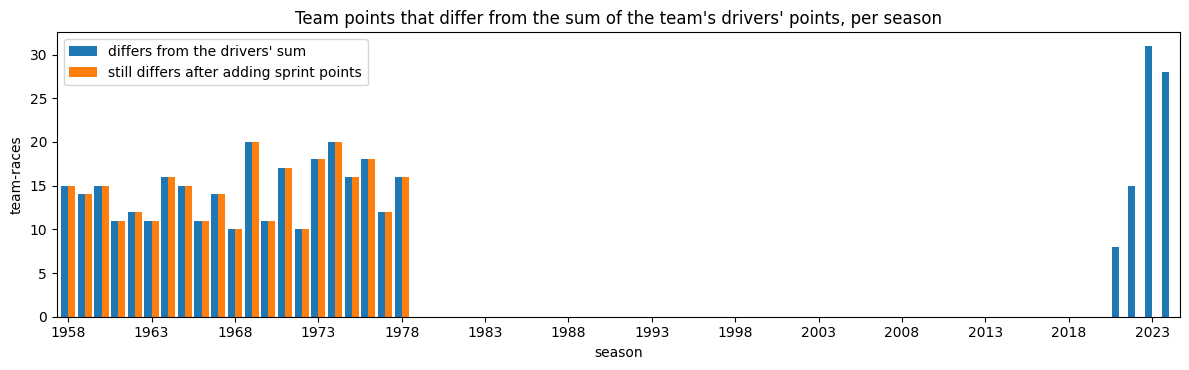

In [17]:
# ------------------------------------------------------------------------------------------
# 2.5  constructor_results: coverage, the empty status column, and does a team's score equal its drivers' points?
# ------------------------------------------------------------------------------------------
cr = constructor_res.merge(races[["raceId", "round", "name"]], on="raceId")
print(pk_check("constructor_results", ["constructorResultsId"]), "|", pk_check("constructor_results", ["raceId", "constructorId"])["duplicates"], "duplicate (raceId, constructorId)")

# (a) Coverage, and how it lines up with the teams that really started (results)
no_rows = races[~races.raceId.isin(cr.raceId)]
print("Seasons:", cr.year.min(), "to", cr.year.max(), "| races with rows:", cr.raceId.nunique(), "of", len(races), "| races with no rows: before 1958 =", int((no_rows.year < 1958).sum()),
      "| from 1958 on =", no_rows[no_rows.year >= 1958][["year", "name"]].values.tolist())
line_up = cr[["raceId", "constructorId"]].merge(team_starts.assign(started=1), on=["raceId", "constructorId"], how="outer", indicator=True)
only_cr = line_up[line_up._merge == "left_only"].merge(cr[["raceId", "constructorId", "year", "round", "name", "points"]], on=["raceId", "constructorId"])
print("Team-races in both tables:", int((line_up._merge == "both").sum()), "| only in constructor_results:", len(only_cr),
      "| only in results:", int((line_up._merge == "right_only").sum()), "(before 1958:", int((line_up[line_up._merge == "right_only"].raceId.map(YEAR) < 1958).sum()), ")")
display(only_cr.assign(team=only_cr.constructorId.map(team))[["year", "round", "name", "team", "points"]])         # a row for a team that has no start in results

# (b) The status column
print("status values:", cr.status.value_counts(dropna=False).to_dict())
flagged = cr[cr.status.notna()]
same_rows = set(zip(flagged.raceId, flagged.constructorId)) == set(zip(cs[cs.positionText == "E"].raceId, cs[cs.positionText == "E"].constructorId))
print("Rows with a status:", len(flagged), "| team and season:", flagged.assign(team=flagged.constructorId.map(team)).groupby(["team", "year"]).size().to_dict(),
      "| the same team-races as the 'E' rows of constructor_standings:", same_rows)

# (c) Does a team's score equal the sum of its drivers' points? (drivers' points from results; sprint points from sprint_results)
drivers_side = results.groupby(["raceId", "constructorId"]).agg(drivers_sum=("points", "sum"), best_car=("points", "max"), cars=("points", "size")).reset_index()
j = cr.merge(drivers_side, on=["raceId", "constructorId"]).merge(sprint_team, on=["raceId", "constructorId"], how="left").fillna({"sprint_points": 0})
j["same_as_drivers"] = (j.points - j.drivers_sum).abs() < 1e-6
j["same_with_sprint"] = (j.points - j.drivers_sum - j.sprint_points).abs() < 1e-6
print("Team-races compared:", len(j), "| team score = drivers' sum:", int(j.same_as_drivers.sum()), f"({j.same_as_drivers.mean() * 100:.2f}%)",
      "| = drivers' sum + sprint points:", int(j.same_with_sprint.sum()), f"({j.same_with_sprint.mean() * 100:.2f}%)")
print("From 1979 on, team-races that are NOT equal (with sprint):", int((~j[j.year >= 1979].same_with_sprint).sum()), "of", int((j.year >= 1979).sum()))
sprint_weekends = j[(j.year >= 2021) & (j.sprint_points > 0)]
print("2021-2024: differences from the drivers' sum =", int((~j[j.year >= 2021].same_as_drivers).sum()), "| team-races with sprint points =", len(sprint_weekends),
      "| equal once the sprint is added:", int(sprint_weekends.same_with_sprint.sum()))
old = j[~j.same_with_sprint]                                                                      # the differences that are left: all before 1979
reason = np.select([(old.points - old.best_car).abs() < 1e-6, (old.points - (old.best_car - 1)).abs() < 1e-6], ["only the best car counted", "best car minus 1 point"], "something else")
print("Differences left after adding the sprint:", len(old), "| seasons", int(old.year.min()), "to", int(old.year.max()), "| team scored less than its drivers:", int((old.points < old.drivers_sum).sum()),
      "| reasons:", pd.Series(reason).value_counts().to_dict())
mc = j[(j.year == 2007) & (j.constructorId == flagged.constructorId.iloc[0])]
print("The excluded team in 2007:", len(mc), "team-races, all equal to its drivers' sum:", bool(mc.same_as_drivers.all()), "| points:", mc.points.sum())

# Figure: where does the official team score differ from the sum of the drivers' points?
by_season = pd.DataFrame({"differs from the drivers' sum": j[~j.same_as_drivers].groupby("year").size(),
                          "still differs after adding sprint points": j[~j.same_with_sprint].groupby("year").size()}).reindex(range(1958, 2025), fill_value=0).fillna(0)
ax = by_season.plot.bar(figsize=(12, 3.8), width=0.85, title="Team points that differ from the sum of the team's drivers' points, per season")
ax.set_xticks(range(0, len(by_season), 5))
ax.set_xticklabels(by_season.index[::5], rotation=0)
plt.xlabel("season")
plt.ylabel("team-races")
save_fig("fig_08_team_vs_drivers")

**What we saw**
- 12,625 rows, keys unique. `status` is `\N` in 12,608 rows and `D` in 17: McLaren 2007, exactly the 17 `E` rows of step 2.4.
- **Coverage:** 1958 to 2024, 1,060 of the 1,125 races (none before 1958, and none for the 1958 Indianapolis 500). 12,618 team-races are in both tables; 7 rows have no team start in `results` (BMW Sauber 2002, Brabham 1979 twice, Marussia 2015 four times) and 410 team starts have no row (400 of them before 1958).
- A team's score equals the sum of its drivers' points in 12,234 of 12,618 team-races (96.96%), and in 12,316 (97.61%) once sprint points are added.
- **From 1979 on, all 9,911 team-races are identical.** In 2021 to 2024 all 82 differences are team-races where the team scored sprint points, and all 82 match once the sprint is added.
- **From 1958 to 1978 the team scored less than its drivers in all 302 remaining differences**: 292 equal the points of the best car only, 9 equal the best car minus 1 point, 1 is something else (Figure 8). McLaren 2007 equals its drivers' sum in all 17 team-races (218 points): the exclusion from the championship is not in the points.

**What we learnt**
- **Team form is built from `results`** (the drivers' points or finishing positions in earlier races). There every car counts the same way in every season, while in `constructor_results` the meaning changes (best car only until 1978, sprint points from 2021). For 2014 to 2024 both sources give the same numbers apart from the sprint weekends.
- `constructor_results` is the outcome of that race, so it may only be used from earlier races. `status` is dropped after we record the McLaren 2007 fact.
- The best-car rule (1958 to 1978) and the sprint rule (2021 on) go into the report, because both change what a "team point" means.

---
## Part 3 · Lap-level tables

`lap_times` and `pit_stops` describe what happens *inside* a race, so for the race we predict they are future information and may only be used from earlier races. The questions here are different: which races have the data, which values are extreme, and does it agree with `results`?

### 3.1 lap_times: what is one row, which races have lap data, and can the time text be trusted?

**Why we look at this.** Lap times could tell us how fast a driver or a team has been recently. Before we look for odd laps we need to know what a row means, where lap data exists at all, and which time column to use (this is also a semantic-typing check: lap-time text to numbers).

In [18]:
# ------------------------------------------------------------------------------------------
# 3.1  lap_times: what is one row, which races have lap data, and can the time text be trusted?
# ------------------------------------------------------------------------------------------
print(pk_check("lap_times", ["raceId", "driverId", "lap"]))
laps_pairs = laps[["raceId", "driverId"]].drop_duplicates()
not_in_results = laps_pairs.merge(driver_races[["raceId", "driverId"]], on=["raceId", "driverId"], how="left", indicator=True)
print("Rows:", len(laps), "| races:", laps.raceId.nunique(), "| drivers:", laps.driverId.nunique(), "| seasons:", laps.year.min(), "to", laps.year.max(),
      "| driver-races with laps but no row in results:", int((not_in_results._merge != "both").sum()))

# (a) Which races have lap data?
print("Races from 1996 on:", int((races.year >= 1996).sum()), "| of them with lap data:", laps.raceId.nunique(), "| races before 1996 with lap data:", laps[laps.year < 1996].raceId.nunique(),
      "| share of ALL races:", round(laps.raceId.nunique() / len(races) * 100, 1), "%")

# (b) What is one row? One completed lap of one driver. Are a driver's laps complete, and what does "position" mean?
per_driver = laps.groupby(["raceId", "driverId"]).lap.agg(["min", "max", "nunique", "size"])
print("Driver-races:", len(per_driver), "| laps run exactly 1..n with no gap:", int(((per_driver["min"] == 1) & (per_driver["max"] == per_driver["nunique"]) & (per_driver["nunique"] == per_driver["size"])).sum()))
per_lap = laps.groupby(["raceId", "lap"]).position.agg(["nunique", "size", "max"])                    # the running order after each lap
print("Race-laps:", len(per_lap), "| all positions different within a lap:", int((per_lap["nunique"] == per_lap["size"]).sum()),
      "| positions run exactly 1..n:", int((per_lap["max"] == per_lap["size"]).sum()))
cars = laps.groupby("raceId").driverId.nunique()                                                      # cars with lap data in each race
laps_in_race = laps.groupby("raceId").lap.max()
print("Laps in a race: shortest", laps_in_race.min(), races[races.raceId == laps_in_race.idxmin()][["year", "name"]].values.tolist(), "| longest", laps_in_race.max(),
      "| cars per race: median", int(cars.median()), "| fewest", cars.min(), races[races.raceId == cars.idxmin()][["year", "name"]].values.tolist())

# (c) The time column is text. Is it always m:ss.mmm, and does it agree with the numeric milliseconds column?
normal = laps.time.str.match(r"^\d+:\d{2}\.\d{3}$")                    # e.g. 1:26.572
with_hours = laps.time.str.match(r"^\d+:\d{2}:\d{2}\.\d{3}$")          # e.g. 2:05:05.152
print("time looks like m:ss.mmm:", int(normal.sum()), "| h:mm:ss.mmm:", int(with_hours.sum()), "| any other format:", int((~normal & ~with_hours).sum()))
def lap_text_to_ms(s):
    parts = s.split(":")
    seconds, minutes = float(parts[-1]), float(parts[-2])
    hours = float(parts[-3]) if len(parts) > 2 else 0.0
    return round(((hours * 60 + minutes) * 60 + seconds) * 1000)
print("time text agrees with the milliseconds column:", int((laps.time.map(lap_text_to_ms) == laps.milliseconds).sum()), "of", len(laps))
long_laps = laps[with_hours].merge(races[["raceId", "name"]], on="raceId")
display(long_laps.groupby(["year", "name"]).agg(rows=("lap", "size"), first_lap=("lap", "min"), last_lap=("lap", "max"), shortest=("time", "min"), longest=("time", "max")))

{'table': 'lap_times', 'key': 'raceId+driverId+lap', 'rows': 589081, 'duplicates': 0, 'missing': 0}
Rows: 589081 | races: 544 | drivers: 143 | seasons: 1996 to 2024 | driver-races with laps but no row in results: 0
Races from 1996 on: 544 | of them with lap data: 544 | races before 1996 with lap data: 0 | share of ALL races: 48.4 %
Driver-races: 11041 | laps run exactly 1..n with no gap: 11041
Race-laps: 33196 | all positions different within a lap: 33196 | positions run exactly 1..n: 33196


Laps in a race: shortest 1 [[2021, 'Belgian Grand Prix']] | longest 87 | cars per race: median 20 | fewest 6 [[2005, 'United States Grand Prix']]


time looks like m:ss.mmm: 589038 | h:mm:ss.mmm: 43 | any other format: 0


time text agrees with the milliseconds column: 589081 of 589081


,,rows,first_lap,last_lap,shortest,longest
year,name,,,,,
2011,Canadian Grand Prix,23,25,25,2:04:29.869,2:05:07.547
2014,British Grand Prix,20,1,2,1:01:07.384,1:03:23.459


**What we saw**
- 589,081 rows, (`raceId`, `driverId`, `lap`) unique, and all 11,041 driver-races exist in `results`.
- **Lap data exists only from 1996**: all 544 races of 1996 to 2024 and none before, which is 48.4% of all races.
- A row is one completed lap of one driver. Every driver-race has laps 1 to n with no gap (11,041 of 11,041). `position` is the running order after that lap: in all 33,196 race-laps the positions are different and run 1 to n. It is not the finishing position.
- A race has 1 to 87 laps. The shortest is the **2021 Belgian GP with a single lap**; the median race has lap data for 20 cars, the smallest field is the **2005 US GP with 6 cars**.
- `time` equals `milliseconds` in all 589,081 rows. 589,038 rows are written `m:ss.mmm` and **43 rows `h:mm:ss.mmm`**: lap 25 of the 2011 Canadian GP (23 cars, about 2 hours 4 to 5 minutes) and laps 1 and 2 of the 2014 British GP (20 cars, about 1 hour 1 to 3 minutes). In both races many cars have the same lap with a time of one or two hours, so this is a stoppage of the whole race (a red flag), not slow driving.

**What we learnt**
- We use `milliseconds`; if the `time` text is ever parsed, the parser must handle hours.
- Lap-based features exist only from 1996, so they need a flag (`has_lap_data`) or a start in 1996. From 2014 on no race is missing.
- The laps of race R only exist once race R has been run: they may only be used for later races.

---

### 3.2 lap_times: extreme laps, and does it agree with results?

**Why we look at this.** A lap time is only a useful pace signal if it is a real racing lap and if we can compare it across circuits. We also check whether `lap_times` tells the same story as the official `results`, so that we know how far we can trust it. We take the median as the typical lap of a race because a few extreme laps would distort an average.

Lap time: median 90608 ms | fastest 55404 ms | slowest 7507547 ms = 125.1 minutes


,year,name,lap,milliseconds
488409,2020,Sakhir Grand Prix,80,55404
8372,2011,Canadian Grand Prix,25,7507547


Typical lap of a race (seconds): fastest race 58.7 | 1% of races below 70.3 | median 91.1 | 99% of races below 122.2 | slowest race 225.4
Relative lap time: median 1.0 | smallest 0.745 | largest 72.7 | lap 1 (standing start) median: 1.131


,laps,% of all laps
slower than 1.2 x typical,38875,6.60
slower than 1.5 x typical,11709,1.99
slower than 2 x typical,1092,0.19
slower than 3 x typical,723,0.12


Laps slower than 1.5 x typical since 2011: 6473 | by reason: {'other: safety car, red flag, spin, rain...': 3855, 'lap after a pit stop': 1222, 'pit stop lap': 903, 'lap 1': 493}


Driver-races: 11041 | lap rows = laps in results: 10951 (99.18%) | different: 90 in 35 of 544 races | differ by 1 or 2 laps: 71 | by 10 laps or more: 10


,year,name,driverId,lap_rows,laps
0,2009,Italian Grand Prix,17,52,0
1,2009,Italian Grand Prix,67,19,52
2,2008,British Grand Prix,21,26,16
3,2006,French Grand Prix,22,18,28
4,2001,Hungarian Grand Prix,15,75,53
5,2001,Hungarian Grand Prix,55,53,75
6,2001,Italian Grand Prix,15,52,0
7,2001,Japanese Grand Prix,15,5,52
8,2001,Japanese Grand Prix,55,52,5
9,2024,São Paulo Grand Prix,807,30,0


The race with most differences: [[2014, 'Chinese Grand Prix']] | difference of every driver there: {2: 20, 0: 2}
Driver-races with a fastest lap in results (from 2004 ): 8249 | same fastest lap in both tables: 8039 (97.5%)


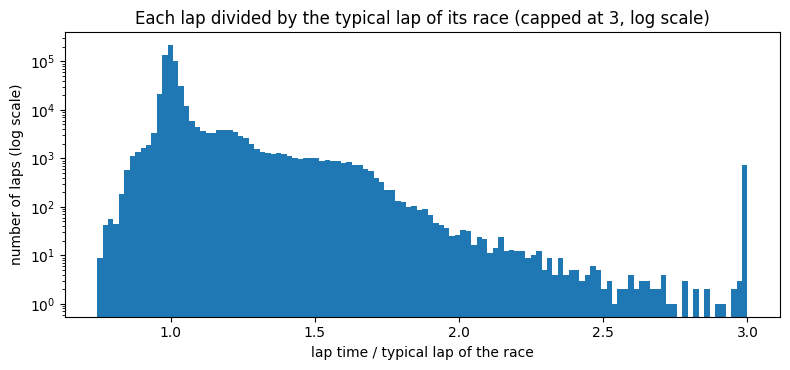

In [19]:
# ------------------------------------------------------------------------------------------
# 3.2  lap_times: extreme laps, why circuits cannot be compared, and does lap_times agree with results?
# ------------------------------------------------------------------------------------------
# (a) The slowest and the fastest laps
with_names = laps.merge(races[["raceId", "name"]], on="raceId")
print("Lap time: median", int(laps.milliseconds.median()), "ms | fastest", laps.milliseconds.min(), "ms | slowest", laps.milliseconds.max(), "ms =", round(laps.milliseconds.max() / 60000, 1), "minutes")
display(pd.concat([with_names.nsmallest(1, "milliseconds"), with_names.nlargest(1, "milliseconds")])[["year", "name", "lap", "milliseconds"]])

# (b) Raw lap times cannot be compared across races: every circuit has its own length. We divide each lap by the typical (median) lap of its own race.
race_median = laps.groupby("raceId").milliseconds.median() / 1000
low, middle, high = race_median.quantile([0.01, 0.5, 0.99])
print("Typical lap of a race (seconds): fastest race", round(race_median.min(), 1), "| 1% of races below", round(low, 1), "| median", round(middle, 1),
      "| 99% of races below", round(high, 1), "| slowest race", round(race_median.max(), 1))
laps["relative"] = laps.milliseconds / laps.groupby("raceId").milliseconds.transform("median")          # 1.0 = a typical lap of its race
print("Relative lap time: median", round(laps.relative.median(), 3), "| smallest", round(laps.relative.min(), 3), "| largest", round(laps.relative.max(), 1),
      "| lap 1 (standing start) median:", round(laps[laps.lap == 1].relative.median(), 3))

# (c) How many laps are extreme, and what are they? (pit stop data exists from 2011, so the reasons can be checked from then on)
slow = pd.DataFrame({"laps": {f"slower than {k} x typical": int((laps.relative > k).sum()) for k in [1.2, 1.5, 2, 3]}})
slow["% of all laps"] = (slow["laps"] / len(laps) * 100).round(2)
display(slow)
pit_laps = pits[["raceId", "driverId", "lap"]].assign(pit_lap=1)                                          # the lap on which a driver stopped
out_laps = pits[["raceId", "driverId", "lap"]].assign(lap=lambda t: t.lap + 1, after_pit=1)               # the lap after a stop
extreme = laps[laps.relative > 1.5].merge(pit_laps, on=["raceId", "driverId", "lap"], how="left").merge(out_laps, on=["raceId", "driverId", "lap"], how="left")
extreme["reason"] = np.select([extreme.lap == 1, extreme.pit_lap == 1, extreme.after_pit == 1], ["lap 1", "pit stop lap", "lap after a pit stop"], "other: safety car, red flag, spin, rain...")
print("Laps slower than 1.5 x typical since 2011:", int((extreme.year >= 2011).sum()), "| by reason:", extreme[extreme.year >= 2011].reason.value_counts().to_dict())

# (d) Does lap_times agree with results? First the number of laps of every driver in every race ...
one_row = results.drop_duplicates(["raceId", "driverId"])                                                  # no repeated driver-races exist from 1996 on
count = laps.groupby(["raceId", "driverId"]).size().rename("lap_rows").reset_index().merge(one_row[["raceId", "driverId", "laps", "fastestLapTime"]], on=["raceId", "driverId"])
count["difference"] = count.lap_rows - count.laps
different = count[count.difference != 0]
print("Driver-races:", len(count), "| lap rows = laps in results:", int((count.difference == 0).sum()), f"({(count.difference == 0).mean() * 100:.2f}%)",
      "| different:", len(different), "in", different.raceId.nunique(), "of", count.raceId.nunique(), "races | differ by 1 or 2 laps:", int((different.difference.abs() <= 2).sum()),
      "| by 10 laps or more:", int((different.difference.abs() >= 10).sum()))
big_gaps = different[different.difference.abs() >= 10].merge(races[["raceId", "year", "name"]], on="raceId")
display(big_gaps[["year", "name", "driverId", "lap_rows", "laps"]])                                         # the biggest differences, listed
worst = different.groupby("raceId").size().idxmax()
print("The race with most differences:", races[races.raceId == worst][["year", "name"]].values.tolist(), "| difference of every driver there:", count[count.raceId == worst].difference.value_counts().to_dict())
# ... then the fastest lap of every driver
fl = count[count.fastestLapTime.notna()].copy()
fl["results_ms"] = fl.fastestLapTime.map(lambda s: round((float(s.split(":")[0]) * 60 + float(s.split(":")[1])) * 1000))
fl = fl.merge(laps.groupby(["raceId", "driverId"]).milliseconds.min().rename("lap_times_ms").reset_index(), on=["raceId", "driverId"])
print("Driver-races with a fastest lap in results (from", int(fl.raceId.map(YEAR).min()), "):", len(fl), "| same fastest lap in both tables:", int((fl.lap_times_ms == fl.results_ms).sum()),
      f"({(fl.lap_times_ms == fl.results_ms).mean() * 100:.1f}%)")

# Figure: each lap divided by the typical lap of its race
laps.relative.clip(upper=3).plot.hist(bins=120, logy=True, figsize=(8, 3.8), title="Each lap divided by the typical lap of its race (capped at 3, log scale)")
plt.xlabel("lap time / typical lap of the race")
plt.ylabel("number of laps (log scale)")
save_fig("fig_09_lap_outliers")

**What we saw**
- The fastest lap is 55.4 s (2020 Sakhir GP, a race whose typical lap is only 58.7 s) and the slowest 125.1 minutes (the 2011 Canadian GP red-flag stop from 3.1).
- **Raw lap times cannot be compared across races.** The typical lap of a race goes from 58.7 s to 225.4 s (the one-lap Belgian GP); for 98% of the races it is between 70.3 s and 122.2 s. Divided by the typical lap of its own race, no lap is impossibly fast (the smallest value is 0.745) (Figure 9).
- **Extreme laps:** 6.6% of the laps are slower than 1.2 times the typical lap, 1.99% (11,709) slower than 1.5 times, 0.19% slower than 2 times and 0.12% (723) slower than 3 times. Lap 1 is slower, with a median of 1.131 times.
- **Why laps are slow** (laps slower than 1.5 times since 2011, when pit data exists; 6,473 laps): 493 are lap 1, 903 are the pit-stop lap, 1,222 the lap after a stop, and **3,855 (60%) have other causes** (safety car, red flag, spin, rain).
- **Lap counts agree with `results` in 10,951 of 11,041 driver-races (99.18%).** 90 differ, in 35 of the 544 races: 71 by only 1 or 2 laps and 10 by 10 laps or more. In the **2014 Chinese GP all 20 classified cars have 2 more laps in `lap_times` than in `results`**.
- The fastest lap of a driver (`results` has it from 2004) is the same in both tables in 8,039 of 8,249 driver-races (97.5%).

**What we learnt**
- Raw lap times are never used: each lap is divided by the typical lap of its own race.
- A pace feature keeps only clean racing laps: it drops lap 1, the pit-stop lap and the lap after a stop (2011 on), and every lap above a cutoff. We propose to start at 1.2 times (removes 6.6% of the laps) and to test 1.5 times (1.99%); the team chooses (open decision 2). Red-flag laps are always out.
- The 90 lap-count differences are recorded and not fixed. If a feature needs lap counts it uses `results.laps`, and the 2014 Chinese GP is excluded from pace features. For a driver's best lap we use one source, not a mix.

---

### 3.3 pit_stops: what is one row, which races have pit data, and how are the time columns written?

**Why we look at this.** Pit stops tell us about a race's strategy and about a team's pit-crew speed. Before we look for odd stops we must know what a row means, where the data exists, whether it is complete, and which time column to use.

In [20]:
# ------------------------------------------------------------------------------------------
# 3.3  pit_stops: what is one row, which races have pit data, is it complete, and how are the time columns written?
# ------------------------------------------------------------------------------------------
print(pk_check("pit_stops", ["raceId", "driverId", "stop"]))
pits_pairs = pits[["raceId", "driverId"]].drop_duplicates()
not_in_results = pits_pairs.merge(driver_races[["raceId", "driverId"]], on=["raceId", "driverId"], how="left", indicator=True)
print("Rows:", len(pits), "| races:", pits.raceId.nunique(), "| seasons:", pits.year.min(), "to", pits.year.max(),
      "| driver-races with stops but no row in results:", int((not_in_results._merge != "both").sum()), "of", len(pits_pairs))

# (a) Which races have pit stop data?
missing_races = races[(races.year >= 2011) & ~races.raceId.isin(pits.raceId)]
print("Races from 2011 on without pit data:", missing_races[["year", "name"]].values.tolist(), "| races before 2011 with pit data:", int((pits.year < 2011).sum()),
      "| share of ALL races:", round(pits.raceId.nunique() / len(races) * 100, 1), "%")

# (b) Is the data complete? A finisher with no stop at all would be suspicious; a driver who retired early may simply have none.
outcome = driver_races.merge(results.drop_duplicates(["raceId", "driverId"])[["raceId", "driverId", "statusId"]], on=["raceId", "driverId"])
outcome = outcome[outcome.raceId.isin(pits.raceId)].merge(status[["statusId", "status"]], on="statusId")
stops = pits.groupby(["raceId", "driverId"]).size().rename("stops").reset_index()
outcome = outcome.merge(stops, on=["raceId", "driverId"], how="left").fillna({"stops": 0})
finished = outcome[outcome.status.eq("Finished") | outcome.status.str.match(r"^\+\d+ Laps?$")]            # classified finishers, also those laps down
print("Race starts in races with pit data:", len(outcome), "| with at least one stop:", int((outcome.stops > 0).sum()), f"({(outcome.stops > 0).mean() * 100:.1f}%)",
      "| finishers:", len(finished), "| finishers with NO stop recorded:", int((finished.stops == 0).sum()),
      "| non-finishers with a stop:", int((outcome.drop(finished.index).stops > 0).sum()), "of", len(outcome) - len(finished))
print("Stops per driver-race:", stops.stops.value_counts().sort_index().to_dict(),
      "| average stops per finisher: 2011 =", round(finished[finished.year == 2011].stops.mean(), 2), "| 2018 =", round(finished[finished.year == 2018].stops.mean(), 2),
      "| 2023 =", round(finished[finished.year == 2023].stops.mean(), 2))

# (c) Are a driver's stops numbered 1..n, and how large are the numbers?
numbering = pits.groupby(["raceId", "driverId"]).stop.agg(["min", "max", "nunique", "size"])
print("Stops numbered exactly 1..n:", int(((numbering["min"] == 1) & (numbering["max"] == numbering["size"]) & (numbering["nunique"] == numbering["size"])).sum()), "of", len(numbering),
      "| stop number up to", pits.stop.max(), "| lap up to", pits.lap.max(), "| duration from", pits.milliseconds.min(), "to", pits.milliseconds.max(), "ms")

# (d) The two time columns: duration (text) and time (text)
normal = pits.duration.str.match(r"^\d{1,3}\.\d{3}$")                  # e.g. 26.898 (seconds)
with_minutes = pits.duration.str.match(r"^\d+:\d{2}\.\d{3}$")          # e.g. 16:44.718 (minutes and seconds)
def duration_to_ms(s):
    parts = s.split(":")
    return round((float(parts[0]) * 60 + float(parts[1])) * 1000) if len(parts) == 2 else round(float(parts[0]) * 1000)
print("duration looks like ss.mmm:", int(normal.sum()), "| m:ss.mmm:", int(with_minutes.sum()), "| other:", int((~normal & ~with_minutes).sum()),
      "| duration text agrees with the milliseconds column:", int((pits.duration.map(duration_to_ms) == pits.milliseconds).sum()), "of", len(pits))
first = pits.raceId.iloc[0]
start = pd.to_timedelta(races.set_index("raceId").time[first])
print("time is a clock time. Example:", races[races.raceId == first].name.iloc[0], races[races.raceId == first].year.iloc[0], "| start time in races:", races.set_index("raceId").time[first],
      "| clock time of its first stop:", pits[pits.raceId == first].time.min())
# A first stop happens minutes after the start. So (first stop clock) - (race start in races) should be close to 0 if both columns used the same clock.
first_stop = pits.groupby("raceId").time.min()
offset = ((pd.to_timedelta(first_stop) - pd.to_timedelta(races.set_index("raceId").time.reindex(first_stop.index))).dt.total_seconds() / 3600).round()   # in whole hours
print("First stop minus race start, in whole hours, over", len(offset), "races: from", int(offset.min()), "to", int(offset.max()), "| most common:", offset.astype(int).value_counts().head(6).to_dict())

{'table': 'pit_stops', 'key': 'raceId+driverId+stop', 'rows': 11371, 'duplicates': 0, 'missing': 0}
Rows: 11371 | races: 285 | seasons: 2011 to 2024 | driver-races with stops but no row in results: 0 of 5575
Races from 2011 on without pit data: [[2021, 'Belgian Grand Prix']] | races before 2011 with pit data: 0 | share of ALL races: 25.3 %
Race starts in races with pit data: 5960 | with at least one stop: 5575 (93.5%) | finishers: 4922 | finishers with NO stop recorded: 3 | non-finishers with a stop: 656 of 1038
Stops per driver-race: {1: 1854, 2: 2225, 3: 1069, 4: 307, 5: 91, 6: 26, 7: 3} | average stops per finisher: 2011 = 2.68 | 2018 = 1.42 | 2023 = 2.2
Stops numbered exactly 1..n: 5567 of 5575 | stop number up to 70 | lap up to 78 | duration from 12897 to 3069017 ms
duration looks like ss.mmm: 10854 | m:ss.mmm: 517 | other: 0 | duration text agrees with the milliseconds column: 11371 of 11371
time is a clock time. Example: Australian Grand Prix 2011 | start time in races: 06:00:00

**What we saw**
- 11,371 rows, (`raceId`, `driverId`, `stop`) unique, and all 5,575 driver-races with stops exist in `results`.
- **Pit data exists only from 2011**: 285 races, which is 25.3% of all races. Every race of 2011 to 2024 has data except the **2021 Belgian GP** (one lap, so no stops).
- **The data is complete for finishers.** 5,575 of the 5,960 race starts in these races (93.5%) have at least one stop. Of the 4,922 classified finishers only 3 have none, while 656 of the 1,038 non-finishers have one, so "no stop row" for a driver who retired early is normal.
- 1,854 driver-races have 1 stop, 2,225 have 2, 1,069 have 3, 307 have 4 and 120 have 5 to 7. The average per finisher moves from 2.68 (2011) to 1.42 (2018) and 2.20 (2023).
- The stops of 5,567 of 5,575 driver-races are numbered exactly 1 to n. The stop number goes up to 70, the lap up to 78 and the duration from 12.9 s up to 3,069 s (51 minutes).
- `duration` is text but equals `milliseconds` in all 11,371 rows. 10,854 rows are `ss.mmm` and **517 are `m:ss.mmm`** (for example `16:44.718`). `time` is a clock time, but not the same clock as `races.time`: the 2011 Australian GP starts at `06:00:00` in `races` and its first stop is at `17:05:23`. A first stop comes minutes after the start, so the difference should be close to 0; instead, over the 285 races, it is a whole number of hours (most often 2, then 3, 8, 4, 1 and 9, from -6 to 16), which looks like time-zone offsets.

**What we learnt**
- We use `milliseconds` for the duration. `time` is dropped (no feature needs it, and it cannot be combined with `races.time`).
- Pit-based features exist only from 2011 and not for the 2021 Belgian GP: they need a flag (`has_pit_data`). Stop counts are not comparable across seasons (1.42 to 2.68 per finisher).
- The pit stops of race R may only be used for later races.

---

### 3.4 pit_stops: real stops versus red-flag pauses

**Why we look at this.** Step 3.3 showed stops of up to 51 minutes and stop numbers up to 70. A real pit stop takes about 24 seconds, so an average stop time or a stop count only means something after we separate real stops from red-flag pauses and from data artifacts.

Stop duration (s): fastest 12.9 | 1% 16.5 | median 23.6 | 90% 31.6 | 99% 1848.2 | slowest 3069.0


,stops,races
longer than 30 s,1664,235
longer than 60 s,517,50
longer than 120 s,481,29
longer than 180 s,478,26
longer than 300 s,478,26


Stops by kind: {'normal (up to 60 s)': 10854, 'red-flag pause (over 5 minutes)': 478, 'very slow stop (1 to 5 minutes)': 39} | middle half of the normal stops (s): 21.9 to 25.6


,,long_stops,all_stops,share
year,name,,,
2023,Australian Grand Prix,49,65,0.75
2016,Brazilian Grand Prix,36,62,0.58
2021,Saudi Arabian Grand Prix,35,47,0.74
2020,Tuscan Grand Prix,25,66,0.38


Red-flag pauses: on lap 1 or 2 = 162 of 478 | in 26 races


,stops,median_drivers_together,made_with_4_or_more_others
kind,,,
red-flag pause (over 5 minutes),478,17.0,461
very slow stop (1 to 5 minutes),39,1.0,10


Driver-races whose stop numbers are not exactly 1..n: 8 | races: {'British Grand Prix': 1, 'Monaco Grand Prix': 6, 'Singapore Grand Prix': 1} | most stop rows of one driver in one race: 7


,year,name,driverId,stop_numbers,laps,durations
0,2014,British Grand Prix,820,"[2, 3]","[2, 29]","[23.154, 29.737]"
1,2019,Singapore Grand Prix,832,[2],[35],[30.623]
2,2024,Monaco Grand Prix,1,"[1, 51]","[1, 2]","[39:35.369, 24.232]"
3,2024,Monaco Grand Prix,822,"[1, 15]","[1, 2]","[39:54.053, 24.239]"


Two stops on the same lap: 0 | a stop not later than the driver's previous stop: 0
Driver-races: 5575 | the stop count changes when the pauses are removed: 404 | driver-races left with 0 stops: 41


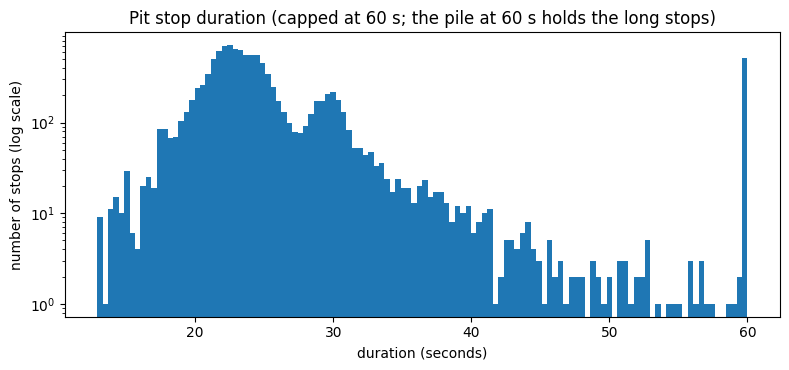

In [21]:
# ------------------------------------------------------------------------------------------
# 3.4  pit_stops: real stops versus red-flag pauses, and the odd stop numbers
# ------------------------------------------------------------------------------------------
# A real pit stop takes about 24 seconds. Which rows are longer than that, and why?
seconds = pits.milliseconds / 1000
low, p10, middle, p90, p99 = seconds.quantile([0.01, 0.10, 0.50, 0.90, 0.99])
print("Stop duration (s): fastest", round(seconds.min(), 1), "| 1%", round(low, 1), "| median", round(middle, 1), "| 90%", round(p90, 1), "| 99%", round(p99, 1), "| slowest", round(seconds.max(), 1))
cut = pd.DataFrame({"stops": {f"longer than {k} s": int((seconds > k).sum()) for k in [30, 60, 120, 180, 300]},
                    "races": {f"longer than {k} s": pits[seconds > k].raceId.nunique() for k in [30, 60, 120, 180, 300]}})
display(cut)
pits["kind"] = np.select([seconds > 300, seconds > 60], ["red-flag pause (over 5 minutes)", "very slow stop (1 to 5 minutes)"], "normal (up to 60 s)")
normal = pits[pits.kind.str.startswith("normal")]
print("Stops by kind:", pits.kind.value_counts().to_dict(), "| middle half of the normal stops (s):",
      round((normal.milliseconds / 1000).quantile(0.25), 1), "to", round((normal.milliseconds / 1000).quantile(0.75), 1))
pauses = pits[pits.kind.str.startswith("red-flag")]
by_race = pits.merge(races[["raceId", "name"]], on="raceId").assign(long=lambda t: t.milliseconds > 60000).groupby(["year", "name"]).agg(long_stops=("long", "sum"), all_stops=("long", "size"))
display(by_race.sort_values("long_stops", ascending=False).head(4).assign(share=lambda t: (t.long_stops / t.all_stops).round(2)))
print("Red-flag pauses: on lap 1 or 2 =", int(pauses.lap.isin([1, 2]).sum()), "of", len(pauses), "| in", pauses.raceId.nunique(), "races")
# Are these long stops made by one driver, or by the whole field at once? We count how many drivers made a long stop on the same lap of the same race.
long_stops = pits[seconds > 60].assign(together=lambda t: t.groupby(["raceId", "lap"]).driverId.transform("nunique"))
by_kind = long_stops.groupby("kind").together.agg(stops="size", median_drivers_together="median", made_with_4_or_more_others=lambda s: int((s >= 5).sum()))
display(by_kind)

# Odd stop numbers: a driver's stops should be numbered 1, 2, 3 ... in the order of the laps
numbering = pits.groupby(["raceId", "driverId"]).agg(first=("stop", "min"), last=("stop", "max"), rows=("stop", "size"),
                                                     stop_numbers=("stop", list), laps=("lap", list), durations=("duration", list)).reset_index()
odd = numbering[(numbering["first"] != 1) | (numbering["last"] != numbering["rows"])]
print("Driver-races whose stop numbers are not exactly 1..n:", len(odd), "| races:", odd.merge(races[["raceId", "name"]], on="raceId").groupby(["name"]).size().to_dict(),
      "| most stop rows of one driver in one race:", int(numbering.rows.max()))
display(odd.merge(races[["raceId", "year", "name"]], on="raceId").head(4)[["year", "name", "driverId", "stop_numbers", "laps", "durations"]])
print("Two stops on the same lap:", int((pits.groupby(["raceId", "driverId", "lap"]).size() > 1).sum()),
      "| a stop not later than the driver's previous stop:", int((pits.sort_values(["raceId", "driverId", "stop"]).groupby(["raceId", "driverId"]).lap.diff() <= 0).sum()))

# What happens to the number of stops if we remove the red-flag pauses?
raw_count = pits.groupby(["raceId", "driverId"]).size()
clean_count = pits[pits.kind != "red-flag pause (over 5 minutes)"].groupby(["raceId", "driverId"]).size().reindex(raw_count.index).fillna(0).astype(int)
print("Driver-races:", len(raw_count), "| the stop count changes when the pauses are removed:", int((raw_count != clean_count).sum()),
      "| driver-races left with 0 stops:", int((clean_count == 0).sum()))

# Figure: how long do pit stops take?
seconds.clip(upper=60).plot.hist(bins=120, logy=True, figsize=(8, 3.8), title="Pit stop duration (capped at 60 s; the pile at 60 s holds the long stops)")
plt.xlabel("duration (seconds)")
plt.ylabel("number of stops (log scale)")
save_fig("fig_10_pit_durations")

**What we saw**
- A real stop is fast: median 23.6 s, 90% under 31.6 s, but the 99th percentile is 1,848 s. The 10,854 stops up to 60 s have a middle half of 21.9 s to 25.6 s (Figure 10).
- **517 stops are longer than 60 s, in 50 races.** 478 of them are **red-flag pauses** (longer than 5 minutes, in 26 races, 162 of them on lap 1 or 2) and 39 are **very slow stops** (1 to 5 minutes). The races with the most: the 2023 Australian GP (49 of its 65 stops), the 2016 Brazilian GP (36 of 62) and the 2021 Saudi Arabian GP (35 of 47).\n- **Where the two cutoffs come from.** Only 3 stops last between 2 and 5 minutes (481 are longer than 120 s, 478 longer than 300 s) and none between 3 and 5 minutes, so any cutoff from 3 to 5 minutes gives the same 478 pauses. These pauses are made together: the median is 17 drivers on the same lap of the same race, and 461 of the 478 were made with at least 4 other drivers, which is what a stoppage of the whole race looks like. Of the 39 slower stops (60 s to 5 minutes) only 10 were made together with others, so they are single slow stops. The 60-second line is our choice (about 2.5 times the median stop); it only decides how those 39 stops are labelled, and we keep them as stops either way.
- **8 driver-races have odd stop numbers.** At the 2024 Monaco GP six drivers have a 39-minute stop on lap 1 and then a normal stop on lap 2 numbered between 15 and 70 instead of 2: the number 70 is a label error, not 70 stops (no driver has more than 7 stop rows in a race). In the 2014 British GP and the 2019 Singapore GP one driver each starts at stop 2, so stop 1 is missing.
- No driver has two stops on the same lap, and every stop is on a later lap than the driver's previous stop.
- Removing the red-flag pauses changes the stop count in 404 of 5,575 driver-races and leaves 41 with 0 stops.

**What we learnt**
- A stop is a **real pit stop up to 60 s**. From 60 s to 5 minutes it is a very slow stop (it counts as a stop but stays out of duration averages). Over 5 minutes it is a red-flag pause and is removed from both durations and stop counts. Stop times are compared with medians.
- The `stop` number is not trusted as a count: stops are recounted by sorting on `lap`. The 8 odd driver-races are recorded in the data-quality log.

---
## Part 4 · All tables together

So far each table was looked at on its own. Now we check how they fit together, how far back each one goes, what exactly is missing, and that the raw files are still intact.

### 4.1 Keys and links: do our 11 tables fit together?

**Why we look at this.** The brief requires that primary keys are unique and non-null, and that foreign keys reconcile: every foreign-key value must exist in the table it points to. We test both for all our tables, and we explain every row that has no partner in `results`.

In [22]:
# ------------------------------------------------------------------------------------------
# 4.1  Keys and links: do our 11 tables fit together?
# ------------------------------------------------------------------------------------------
# (a) Primary keys: does each table identify its rows exactly once? (no duplicates, no missing values)
keys = [("seasons", ["year"]), ("circuits", ["circuitId"]), ("drivers", ["driverId"]), ("constructors", ["constructorId"]), ("status", ["statusId"]),
        ("sprint_results", ["resultId"]), ("sprint_results", ["raceId", "driverId"]),
        ("driver_standings", ["driverStandingsId"]), ("driver_standings", ["raceId", "driverId"]),
        ("constructor_standings", ["constructorStandingsId"]), ("constructor_standings", ["raceId", "constructorId"]),
        ("constructor_results", ["constructorResultsId"]), ("constructor_results", ["raceId", "constructorId"]),
        ("lap_times", ["raceId", "driverId", "lap"]), ("pit_stops", ["raceId", "driverId", "stop"])]
pk = pd.DataFrame([pk_check(t, cols) for t, cols in keys]).set_index("table")
display(pk)
print("Keys with a duplicate or a missing value:", int(((pk.duplicates > 0) | (pk.missing > 0)).sum()), "of", len(pk))

# (b) Foreign keys: does every id point at a real row of the table it belongs to? (an "orphan" is an id with no parent row)
links = [("sprint_results", "raceId", "races", "raceId"), ("sprint_results", "driverId", "drivers", "driverId"),
         ("sprint_results", "constructorId", "constructors", "constructorId"), ("sprint_results", "statusId", "status", "statusId"),
         ("driver_standings", "raceId", "races", "raceId"), ("driver_standings", "driverId", "drivers", "driverId"),
         ("constructor_standings", "raceId", "races", "raceId"), ("constructor_standings", "constructorId", "constructors", "constructorId"),
         ("constructor_results", "raceId", "races", "raceId"), ("constructor_results", "constructorId", "constructors", "constructorId"),
         ("lap_times", "raceId", "races", "raceId"), ("lap_times", "driverId", "drivers", "driverId"),
         ("pit_stops", "raceId", "races", "raceId"), ("pit_stops", "driverId", "drivers", "driverId"),
         ("races", "circuitId", "circuits", "circuitId"), ("races", "year", "seasons", "year"),
         ("results", "raceId", "races", "raceId"), ("results", "driverId", "drivers", "driverId"),
         ("results", "constructorId", "constructors", "constructorId"), ("results", "statusId", "status", "statusId")]
fk = pd.DataFrame([{"child column": f"{c}.{cc}", "points at": f"{p}.{pc}", "orphans": int((~raw[c][cc].isin(set(raw[p][pc]))).sum())} for c, cc, p, pc in links])
display(fk)
print("Links checked:", len(fk), "| orphans in total:", int(fk.orphans.sum()))
assert fk.orphans.sum() == 0, "some id points at a row that does not exist"                    # the notebook stops here if this ever changes

# (c) Do the per-driver and per-team tables only contain driver-races and team-races that really happened (exist in results)?
race_driver = set(zip(driver_races.raceId, driver_races.driverId))
race_team = set(zip(team_starts.raceId, team_starts.constructorId))
outside_driver = {t: sum((a, b) not in race_driver for a, b in zip(df.raceId, df.driverId)) for t, df in [("sprint_results", sprint), ("driver_standings", driver_st), ("lap_times", laps), ("pit_stops", pits)]}
outside_team = {t: sum((a, b) not in race_team for a, b in zip(df.raceId, df.constructorId)) for t, df in [("sprint_results", sprint), ("constructor_standings", constructor_st), ("constructor_results", constructor_res)]}
print("Rows whose (raceId, driverId) has no row in results:", outside_driver)
print("Rows whose (raceId, constructorId) has no team start in results:", outside_team)

# (d) The other direction: rows that nothing points at
used = {"drivers": set(results.driverId) | set(sprint.driverId) | set(driver_st.driverId) | set(laps.driverId) | set(pits.driverId),
        "constructors": set(results.constructorId) | set(sprint.constructorId) | set(constructor_st.constructorId) | set(constructor_res.constructorId),
        "status": set(results.statusId) | set(sprint.statusId)}
unused = [{"table": t, "id": row[col], "name": row[label]} for t, (col, label) in {"drivers": ("driverId", "driverRef"), "constructors": ("constructorId", "name"), "status": ("statusId", "status")}.items()
          for _, row in raw[t].iterrows() if int(row[col]) not in used[t]]
print("Circuits not used by any race:", len(set(circuits.circuitId) - set(races.circuitId)), "| seasons without a race:", len(set(seasons.year) - set(races.year)),
      "| races without a result row:", len(set(races.raceId) - set(results.raceId)))
display(pd.DataFrame(unused))                                                                  # reference rows that no table uses

,key,rows,duplicates,missing
table,,,,
seasons,year,75,0,0
circuits,circuitId,77,0,0
drivers,driverId,861,0,0
constructors,constructorId,212,0,0
status,statusId,139,0,0
sprint_results,resultId,360,0,0
sprint_results,raceId+driverId,360,0,0
driver_standings,driverStandingsId,34863,0,0
driver_standings,raceId+driverId,34863,0,0


Keys with a duplicate or a missing value: 0 of 15


,child column,points at,orphans
0,sprint_results.raceId,races.raceId,0
1,sprint_results.driverId,drivers.driverId,0
2,sprint_results.constructorId,constructors.constructorId,0
3,sprint_results.statusId,status.statusId,0
4,driver_standings.raceId,races.raceId,0
5,driver_standings.driverId,drivers.driverId,0
6,constructor_standings.raceId,races.raceId,0
7,constructor_standings.constructorId,constructors.constructorId,0
8,constructor_results.raceId,races.raceId,0
9,constructor_results.constructorId,constructors.constructorId,0


Links checked: 20 | orphans in total: 0
Rows whose (raceId, driverId) has no row in results: {'sprint_results': 0, 'driver_standings': 8664, 'lap_times': 0, 'pit_stops': 0}
Rows whose (raceId, constructorId) has no team start in results: {'sprint_results': 0, 'constructor_standings': 892, 'constructor_results': 7}


Circuits not used by any race: 0 | seasons without a race: 0 | races without a result row: 0


,table,id,name
0,constructors,88,Eagle
1,status,133,+49 Laps
2,status,134,+38 Laps


**What we saw**
- **All 15 keys are valid**: no duplicate and no missing value in the single ids and in the combinations (`raceId`, `driverId`), (`raceId`, `constructorId`), (`raceId`, `driverId`, `lap`) and (`raceId`, `driverId`, `stop`).
- **All 20 links reconcile: 0 orphans.** Every id points at a real row. The notebook stops with an error if this ever changes.
- Rows whose (`raceId`, `driverId`) has no row in `results`: `sprint_results` 0, `lap_times` 0, `pit_stops` 0, and `driver_standings` **8,664** (the carried-forward drivers of step 2.2). Rows whose (`raceId`, `constructorId`) has no team start: `sprint_results` 0, `constructor_standings` **892** (step 2.4) and `constructor_results` **7** (step 2.5).
- Nothing is unused except 3 reference rows that no table points at: the constructor Eagle and the statuses `+49 Laps` and `+38 Laps`. Every circuit, every season and every race is used.

**What we learnt**
- Nothing needs fixing. Every count above zero is explained by an earlier step.
- **Join recipe for the cleaning task:** build the driver-race table from `results`, left-join the other tables on (`raceId`, `driverId`) or (`raceId`, `constructorId`), and take the standings from the previous round of the same season (step 2.3). The extra rows then drop out by themselves.

---

### 4.2 Coverage over time: which seasons does each table cover?

**Why we look at this.** Our tables do not all start in the same year, so any feature built from them is missing in the earlier seasons. The brief lists coverage drift as a limitation that the report must state, so we measure it for every table and every season.

,first season,races with rows,"% of all 1,125 races",seasons fully covered,seasons partly covered
results,1950,1125,100.0,75,0
driver_standings,1950,1125,100.0,75,0
constructor_standings,1958,1061,94.3,67,0
constructor_results,1958,1060,94.2,66,1
lap_times,1996,544,48.4,29,0
pit_stops,2011,285,25.3,13,1
sprint_results,2021,18,1.6,0,4


Seasons that are only partly covered: {'constructor_results': {1958: 0.91}, 'pit_stops': {2021: 0.95}}
Sprint results, share of the races of each sprint season (%): {2021: 14, 2022: 14, 2023: 27, 2024: 25}


,% of races 2014-2021,% of races 2022-2024
results,100.0,100.0
driver_standings,100.0,100.0
constructor_standings,100.0,100.0
constructor_results,100.0,100.0
lap_times,100.0,100.0
pit_stops,99.4,100.0
sprint_results,1.9,22.1


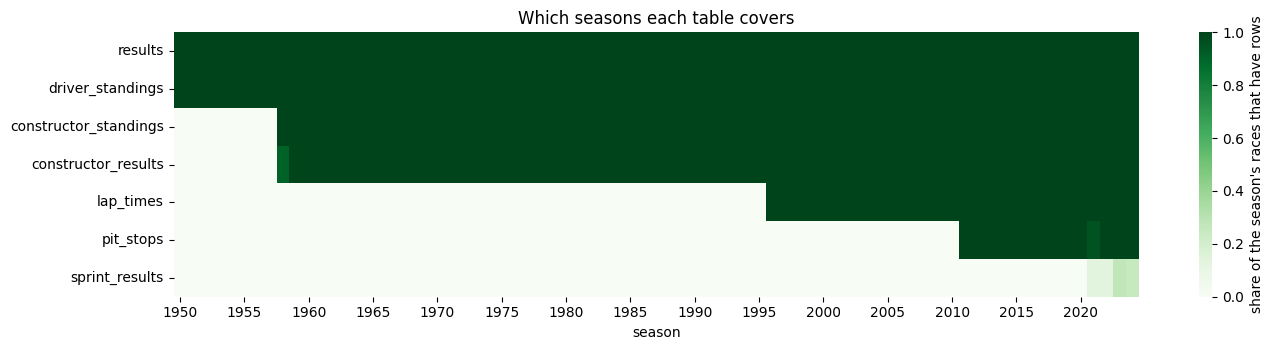

In [23]:
# ------------------------------------------------------------------------------------------
# 4.2  Coverage over time: which seasons does each table cover?
# ------------------------------------------------------------------------------------------
race_tables = {"results": results, "driver_standings": driver_st, "constructor_standings": constructor_st, "constructor_results": constructor_res,
               "lap_times": laps, "pit_stops": pits, "sprint_results": sprint}                                      # results = the reference
races_per_year = races.groupby("year").size()
with_rows = pd.DataFrame({t: df.groupby("year").raceId.nunique() for t, df in race_tables.items()})
share = with_rows.reindex(range(1950, 2025)).fillna(0).div(races_per_year, axis=0)                                  # 1.0 = every race of the season has rows
summary = pd.DataFrame({"first season": share.apply(lambda col: int(col[col > 0].index.min())),
                        "races with rows": [int(df.raceId.nunique()) for df in race_tables.values()],
                        "% of all 1,125 races": [round(df.raceId.nunique() / len(races) * 100, 1) for df in race_tables.values()],
                        "seasons fully covered": (share == 1).sum(), "seasons partly covered": ((share > 0) & (share < 1)).sum()})
display(summary)
print("Seasons that are only partly covered:", {t: {int(y): round(v, 2) for y, v in share[t][(share[t] > 0) & (share[t] < 1)].items()} for t in share.columns if t != "sprint_results" and ((share[t] > 0) & (share[t] < 1)).any()})
print("Sprint results, share of the races of each sprint season (%):", {int(y): round(v * 100) for y, v in share.sprint_results[share.sprint_results > 0].items()})

# The two periods of the brief
periods = {"2014-2021": (2014, 2021), "2022-2024": (2022, 2024)}
brief = pd.DataFrame({f"% of races {name}": {t: round(float(with_rows[t].reindex(range(a, b + 1)).fillna(0).sum() / races_per_year.loc[a:b].sum() * 100), 1) for t in share.columns}
                      for name, (a, b) in periods.items()})
display(brief)

plt.figure(figsize=(14, 3.6))
sns.heatmap(share.T, cmap="Greens", vmin=0, vmax=1, xticklabels=5, cbar_kws={"label": "share of the season's races that have rows"})
plt.title("Which seasons each table covers")
plt.xlabel("season")
save_fig("fig_11_coverage_over_time")

**What we saw** (Figure 11)

| Table | First season | Races with rows | Share of all 1,125 races |
|---|---|---|---|
| `results`, `driver_standings` | 1950 | 1,125 | 100% |
| `constructor_standings` | 1958 | 1,061 | 94.3% |
| `constructor_results` | 1958 | 1,060 | 94.2% |
| `lap_times` | 1996 | 544 | 48.4% |
| `pit_stops` | 2011 | 285 | 25.3% |
| `sprint_results` | 2021 | 18 | 1.6% |

- The coverage steps up four times: 1958, 1996, 2011 and 2021.
- Only a few seasons are partly covered: `constructor_results` in 1958 (91%, it misses the Indianapolis 500), `pit_stops` in 2021 (95%, it misses the one-lap Belgian GP) and `sprint_results` (14%, 14%, 27% and 25% of the races of 2021 to 2024).
- **The two periods of the brief are almost fully covered.** In 2014 to 2021 and in 2022 to 2024 every table covers 100% of the races, except `pit_stops` in 2014 to 2021 (99.4%) and `sprint_results` (1.9% and 22.1%).

**What we learnt**
- This figure and table go into the report's limitations section: lap and pit features simply do not exist for 52% and 75% of all races.
- Lap and pit features get the flags `has_lap_data` (from 1996) and `has_pit_data` (from 2011), and any sprint feature gets `has_sprint`. Earlier seasons are never filled with an average: they stay missing, or the model that uses these features is trained only on the seasons that have them.
- If one model is trained on all seasons, we keep a **core feature set** that exists in every season (results, grid, standings from the previous round) and an **extended set** (laps, pit stops), and we report the score per era so the drift is visible.

---

### 4.3 Missing values (`\N`) and the type conversions our tables need

**Why we look at this.** The brief asks us to clean the placeholder `\N` and to apply semantic typing (dates to dates, lap-time strings to numeric seconds). Before cleaning we list exactly where `\N` is, why it is there, and which conversions are needed, and we test every conversion on all rows so that the cleaning step cannot lose anything. Because the brief says sentinels \"such as\" `\N`, we also check whether `\N` is really the only way a missing value is written.

In [24]:
# ------------------------------------------------------------------------------------------
# 4.3  Missing values (\N) and the type conversions our tables need
# ------------------------------------------------------------------------------------------
# (a) Every column that contains \N in our 11 tables, with the reason we found for it in the steps above
missing = pd.concat({t: profile(t) for t in MINE})
missing.index.names = ["table", "column"]
missing = missing[missing["missing (\\N)"] > 0][["missing (\\N)", "missing %"]]
reason = {("drivers", "number"): "no permanent car number before 2014: follows the era (1.2)",
          ("drivers", "code"): "three-letter codes became common in the 2000s: follows the era (1.2)",
          ("sprint_results", "position"): "empty = did not finish the sprint (2.1)",
          ("sprint_results", "time"): "empty = no race time, a driver who did not finish (2.1)",
          ("sprint_results", "milliseconds"): "empty = no race time, a driver who did not finish (2.1)",
          ("sprint_results", "fastestLap"): "empty = no timed fastest lap (2.1)",
          ("sprint_results", "fastestLapTime"): "empty = no timed fastest lap (2.1)",
          ("constructor_results", "status"): "only value is D: McLaren 2007, 17 rows (2.5)"}
missing["why it is missing"] = [reason.get(key, "NOT EXPLAINED YET: investigate") for key in missing.index]
display(missing)
assert all(key in reason for key in missing.index), "a column with missing values has no explanation yet"       # the notebook stops if a new one ever appears
print("Columns with missing values:", len(missing), "in", missing.index.get_level_values("table").nunique(), "of our", len(MINE), "tables | tables with none:",
      [t for t in MINE if t not in missing.index.get_level_values("table")])
print("Cells that are empty text (not \\N) in our tables:", int(sum((raw[t] == "").sum().sum() for t in MINE)))

# (b) Is \N the ONLY way a missing value is written? We scan EVERY column of our 11 tables for other common placeholders:
#     placeholder text ("NaN", "N/A", "null", "-", "?", ...), stray spaces, and numbers that often stand in for "missing" (-1, 9999, ...).
PLACEHOLDER_TEXT = {"", "nan", "na", "n/a", "null", "none", "nil", "-", "--", "?", "unknown", "unk", "tbd", "missing"}
SENTINEL_NUMBERS = {"-1", "-99", "-999", "9999", "99999"}
hits = []
for t in MINE:
    for col in raw[t].columns:
        values = raw[t][col][raw[t][col] != SENT]                                                    # the known \N is left out
        found = {"placeholder text": int(values.str.strip().str.lower().isin(PLACEHOLDER_TEXT).sum()),
                 "stray spaces": int((values != values.str.strip()).sum()),
                 "sentinel-like number": int(values.isin(SENTINEL_NUMBERS).sum())}
        hits += [{"table": t, "column": col, "kind": k, "values": n} for k, n in found.items() if n]
explanation = {("drivers", "nationality", "stray spaces"): "one value with a trailing space (Argentinian), fixed in step 1.4",
               ("lap_times", "milliseconds", "sentinel-like number"): "laps of exactly 99,999 ms, which is the real lap time " + " / ".join(laps[laps.milliseconds == 99999].time.unique()),
               ("constructor_results", "constructorResultsId", "sentinel-like number"): "an id that happens to be 9999, not a missing value"}
scan = pd.DataFrame(hits)
scan["explained by"] = [explanation.get((r.table, r.column, r.kind), "NOT EXPLAINED YET: investigate") for r in scan.itertuples()]
print("Columns scanned:", sum(raw[t].shape[1] for t in MINE), "| findings of the scan (all listed below):", len(scan), "| of them placeholder text:", int((scan.kind == "placeholder text").sum()))
display(scan)
assert not scan["explained by"].str.startswith("NOT EXPLAINED").any(), "the scan found something we cannot explain yet"

# (c) Columns that are stored as text but must become real numbers, dates or durations. We test every conversion on ALL rows.
conversions = pd.DataFrame([
    ("drivers.dob",            "text YYYY-MM-DD",                   "date",                f"{int(dob.notna().sum())} of {len(dob)} read as dates"),
    ("lap_times.time",         "text m:ss.mmm (43 with hours)",     "seconds (number)",    f"{int((laps.time.map(lap_text_to_ms) == laps.milliseconds).sum())} of {len(laps)} equal milliseconds"),
    ("pit_stops.duration",     "text ss.mmm (517 with minutes)",    "seconds (number)",    f"{int((pits.duration.map(duration_to_ms) == pits.milliseconds).sum())} of {len(pits)} equal milliseconds"),
    ("sprint_results.time",    "text 25:38.426 or +1.430",          "seconds (number)",    f"{int((timed.expected_ms == timed.milliseconds).sum())} of {len(timed)} equal milliseconds"),
    ("drivers.number",         "text, with \\N",                     "whole number",        f"{int(drivers.number.notna().sum())} values read as numbers, {int(drivers.number.isna().sum())} stay missing"),
    ("circuits lat, lng, alt", "text",                              "decimal number",      f"{int(circuits[['lat', 'lng', 'alt']].notna().all(axis=1).sum())} of {len(circuits)} rows read as numbers")],
    columns=["column", "stored as", "must become", "checked on all rows"]).set_index("column")
display(conversions)

missing (\N)  missing %                                                     why it is missing
table               column                                                                                                       
drivers             number                   802      93.15            no permanent car number before 2014: follows the era (1.2)
                    code                     757      87.92  three-letter codes became common in the 2000s: follows the era (1.2)
sprint_results      position                  15       4.17                               empty = did not finish the sprint (2.1)
                    time                      20       5.56               empty = no race time, a driver who did not finish (2.1)
                    milliseconds              20       5.56               empty = no race time, a driver who did not finish (2.1)
                    fastestLap                 9       2.50                                    empty = no timed fastest lap (2.1)
                    fastestLapTime             9       2.50                                    empty = no timed fastest lap (2.1)
constructor_results status                 12608      99.87                          only value is D: McLaren 2007, 17 rows (2.5)

Columns with missing values: 8 in 3 of our 11 tables | tables with none: ['seasons', 'circuits', 'constructors', 'status', 'driver_standings', 'lap_times', 'pit_stops', 'constructor_standings']
Cells that are empty text (not \N) in our tables: 0


Columns scanned: 75 | findings of the scan (all listed below): 3 | of them placeholder text: 0


,table,column,kind,values,explained by
0,drivers,nationality,stray spaces,1,"one value with a trailing space (Argentinian), fixed in step 1.4"
1,lap_times,milliseconds,sentinel-like number,13,"laps of exactly 99,999 ms, which is the real lap time 1:39.999"
2,constructor_results,constructorResultsId,sentinel-like number,1,"an id that happens to be 9999, not a missing value"


,stored as,must become,checked on all rows
column,,,
drivers.dob,text YYYY-MM-DD,date,861 of 861 read as dates
lap_times.time,text m:ss.mmm (43 with hours),seconds (number),589081 of 589081 equal milliseconds
pit_stops.duration,text ss.mmm (517 with minutes),seconds (number),11371 of 11371 equal milliseconds
sprint_results.time,text 25:38.426 or +1.430,seconds (number),340 of 340 equal milliseconds
drivers.number,"text, with \N",whole number,"59 values read as numbers, 802 stay missing"
"circuits lat, lng, alt",text,decimal number,77 of 77 rows read as numbers


**What we saw**
- **8 columns contain `\N`, in 3 of our 11 tables**, and each has a reason we found above: `drivers.number` (93.15%) and `drivers.code` (87.92%) follow the era; five `sprint_results` columns (2.5% to 5.6%) are empty for drivers who did not finish; `constructor_results.status` (99.87%) only holds the flag `D` for McLaren 2007. The other 8 tables have no missing value at all, and no table has a truly empty cell. The notebook stops if a column with `\N` ever has no explanation.
- **`\N` is the only missing marker we can find.** We scanned all 75 columns for other placeholders (`NaN`, `N/A`, `null`, `-`, `?`, empty text), stray spaces and numbers that often stand in for missing (-1, 9999, ...). We found no placeholder text. The 3 findings are all explained: one value with a trailing space (fixed in step 1.4), 13 laps of exactly 99,999 ms (the real lap time `1:39.999`) and one id that happens to be 9999. A scan cannot prove that nothing else hides, but it covers the usual candidates.
- **The conversions work on every row:** all 861 dates of birth read as dates; the lap-time text equals `milliseconds` in 589,081 of 589,081 rows, the pit-stop duration text in 11,371 of 11,371, the sprint time text in 340 of 340; the circuit coordinates read as numbers in 77 of 77 rows.

**What we learnt**
- The cleaning task converts exactly these columns: `\N` becomes a real missing value in the cleaned copies, `dob` becomes a date, and lap, pit and sprint times become numeric seconds from the numeric `milliseconds` column.
- Missing cells are never filled without a reason: `number` and `code` stay missing (labels, era-driven), and the empty sprint cells keep meaning "did not finish".

---

### 4.4 Proof that the raw tables were never changed

**Why we look at this.** The brief says raw CSV files remain immutable and cleaning happens on copies. In step 0.1 we stored a fingerprint (hash) of every raw table. If any step above had modified a raw table, its fingerprint would be different now.

In [25]:
# ------------------------------------------------------------------------------------------
# 4.4  Proof that the raw tables were never changed
# ------------------------------------------------------------------------------------------
# In step 0.1 we stored a fingerprint (hash) of every raw table. If any step had modified a raw table, its fingerprint would be different now.
now = {t: pd.util.hash_pandas_object(df).sum() for t, df in raw.items()}
changed = [t for t in raw if now[t] != RAW_HASH[t]]
assert not changed, f"raw tables were modified: {changed}"
print("Raw tables compared with their fingerprint from step 0.1:", len(raw), "| changed:", len(changed))
print("raw tables unchanged")

Raw tables compared with their fingerprint from step 0.1: 13 | changed: 0
raw tables unchanged


**What we saw**
- All 13 raw tables loaded in step 0.1 (our 11, plus `races` and `results`) have exactly the same fingerprint as when they were loaded: **0 changed**. The notebook prints `raw tables unchanged` and would stop with an error otherwise.

**What we learnt**
- The raw layer is intact, and every step worked on copies. The cleaning task starts from these files and writes its output to a new layer.

---
## Part 5 · What we learnt

### 5.1 What this audit changed in our plan

| # | What we found | Where | What we do about it | Used for |
|---|---|---|---|---|
| 1 | All 15 keys are unique and all 20 links reconcile (0 orphans); every row without a partner in `results` is explained | 4.1 | Nothing to fix. Build the driver-race table from `results` and left-join the rest | Cleaning, joins |
| 2 | `results` repeats 85 driver-races (shared drives, 1950 to 1964 and 1978) | 0.2 | The cleaning task chooses and documents one rule for the modelling table; our counts use one row per driver-race | Cleaning (grain) |
| 3 | `\N` is in only 8 columns and each has a reason: 2 follow the era, 5 are sprint cells of drivers who did not finish, 1 is a nearly empty flag | 1.2, 2.1, 2.5, 4.3 | `\N` becomes a real missing value; nothing is filled; `constructor_results.status` is dropped | Cleaning |
| 4 | Dates and durations convert without loss: `dob`, lap time, pit duration, sprint time | 1.3, 3.1, 3.3, 4.3 | Dates become dates; durations become numeric seconds from `milliseconds` | Cleaning (typing) |
| 5 | Driver and team standings are written **after** the race and include the sprint; the same-race standings leak (rank correlation 0.57 against 0.46 before the race) | 2.3, 2.4 | Use only the previous round of the same season; round 1 gets a start value and a flag; order by season and round, because `raceId` is not in date order | Leakage, features |
| 6 | `constructor_results` changes meaning (best car only until 1978, sprint points from 2021); the team tables start in 1958 | 2.4, 2.5 | Build team form from `results` (earlier races) | Features |
| 7 | The sprint covers 1.6% of the races and in 2021 and 2022 repeats the Sunday grid | 2.1 | Not in the main model; at most an optional experiment with `has_sprint` | Features |
| 8 | Coverage steps up in 1958 (teams), 1996 (laps), 2011 (pit stops) and 2021 (sprint) | 4.2 | Flags, never fill earlier seasons, core and extended feature sets, score per era | Features, report limitation |
| 9 | Lap times are not comparable across circuits; 6.6% of the laps are slower than 1.2 times the typical lap; lap counts match `results` in 99.18% | 3.2 | Relative laps, a clean-lap rule, `results.laps` for counts | Features, cleaning |
| 10 | 478 pit-stop rows are red-flag pauses; 8 driver-races have odd stop numbers | 3.4 | Remove the pauses, recount stops by lap, record the odd cases | Features, cleaning |
| 11 | Points and counts are not comparable across seasons (7 to 24 races per season, champions from 30 to 575 points) | 1.1, 2.2, 2.5 | Rates, shares, positions and gaps to the leader | Features |
| 12 | Only 16 circuits have at least 5 races in both eras; countries and nationalities need a written map; the Indianapolis 500 inflates the American home races about four times | 1.1, 1.4 | Question 1: a minimum number of races per era. Question 2: the map, and exclude the Indianapolis 500 | Questions 1 and 2 |
| 13 | 139 statuses, 29 of them in a grey zone: the mechanical rate is 9.2% then 5.6% (clear) or 11.4% then 7.0% (with the grey zone); status is known only after the race | 1.6 | Question 3 reports both definitions; `statusId` is never a feature | Question 3, leakage |
| 14 | A `constructorId` is not one continuous team (70 one-season teams, engine splits, reused ids) | 1.5 | Team features from a recent window, a minimum number of starts, exclude the Indianapolis 500 chassis | Question 3, features |
| 15 | `driverId` is the only safe driver key; age comes from `dob`; `number` and `code` are era-driven labels | 1.2, 1.3 | `driver_age` is allowed before the race; numbers and codes are not features | Cleaning, features |
| 16 | The raw files are unchanged (13 fingerprints) | 4.4 | The cleaning task starts from them and writes to a new layer | Cleaning |

### 5.2 What is still open

These are choices the data cannot make for us. For each one we give the evidence and our proposal; the team decides.

| # | Open decision | Our proposal | Step |
|---|---|---|---|
| 1 | Use the sprint result in the main model? | No (1.6% of races, repeats the Sunday grid in 2021 and 2022). At most an optional experiment with `has_sprint` | 2.1 |
| 2 | Cutoff for a "clean" lap | Start at 1.2 times the typical lap of the race (removes 6.6% of the laps) and test 1.5 times (1.99%) | 3.2 |
| 3 | Start value of the standings features in round 1 | A documented start value (0 points, position unknown) plus a flag; the alternative is last season's final standing | 2.3, 2.4 |
| 4 | Team form before 1958 and in round 1 | A flag, or start the team window in 1958, or take team form from `results` for every season | 2.4, 2.5 |
| 5 | Question 3: the grey zone of the status grouping | Finalise the draft, argue each grey status, report the rates with and without the grey zone and say which is the headline | 1.6 |
| 6 | Question 2: the nationality map | Finish the map, decide the 4 mixed or historical nationalities, exclude the Indianapolis 500 or report with and without it | 1.4 |
| 7 | Question 1: minimum races per circuit | At least 5 races in each era (16 circuits) | 1.1 |
| 8 | Question 3: minimum starts per constructor | Set a minimum, mention the renames, exclude the Indianapolis 500 chassis | 1.5 |
| 9 | Source of a driver's best lap | One source only: `lap_times` (from 1996) or `results.fastestLapTime` (from 2004); they agree for 97.5% | 3.2 |
| 10 | Which seasons a model trains on | The brief's windows (2014 to 2021, 2022 to 2024) have full lap and pit coverage; for all seasons compare the core set with the extended set | 4.2 |
| 11 | The podium label before 1960 | Decide which row to keep for the repeated driver-races and how to label the 18 races (1950 to 1960) that have more than 3 drivers on `positionOrder <= 3` | 0.2 |